In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # registers the 'science' / 'ieee' styles
from collections import Counter
import matplotlib.patches as mpatches
import os
import seaborn as sns

# Define options
num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']


def smooth_curve(values, weight):
    """TensorBoard-style EMA smoothing. weight=0 returns values unchanged; weight up to 0.99 smooths more heavily."""
    if weight <= 0:
        return list(values)
    last = 0.0
    smoothed = []
    for i, v in enumerate(values, start=1):
        last = last * weight + (1 - weight) * v
        smoothed.append(last / (1 - weight ** i))
    return smoothed

# ---- Global plot styling ----
# Fixed, ordered color vector shared by every plot below except scatter_time_performance
# (which keeps its own long-standing manual palette). Colors are used in order: a plot
# that needs 2 colors gets the first 2, one that needs 12 gets all 12, and so on - edit
# this list directly to change what every plot uses. The defaults below are sampled
# once from 'cividis' (perceptually uniform, so monotonic in greyscale) at 12 evenly
# spaced points, which makes them colorblind-safe and print/greyscale-safe as a set.
COLOR_PALETTE = [
     '#2b83ba', '#fdae61', '#abdda4','#d7191c','#ffffbf'
]

#d7191c
#fdae61
#ffffbf
#abdda4
#2b83ba

# Uniform font sizes applied to every plot's axis labels, tick labels, and legend below.
TITLE_FONT_SIZE = 12         # plot title
FONT_SIZE_LABEL = 12          # xlabel / ylabel
FONT_SIZE_TICK = 12           # x/y tick labels
FONT_SIZE_LEGEND = 12         # legend entries
FONT_SIZE_LEGEND_TITLE = 12   # legend title

def get_colors(n):
    """First n colors from COLOR_PALETTE, in order (cycles if n exceeds its length)."""
    return [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(n)]


all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#33a02c', '#fb9a99', 
    '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
     "#e704eb", "#000000"
]

#plt.style.use(['science', 'ieee'])
plt.style.use(['science', 'muted', 'no-latex'])

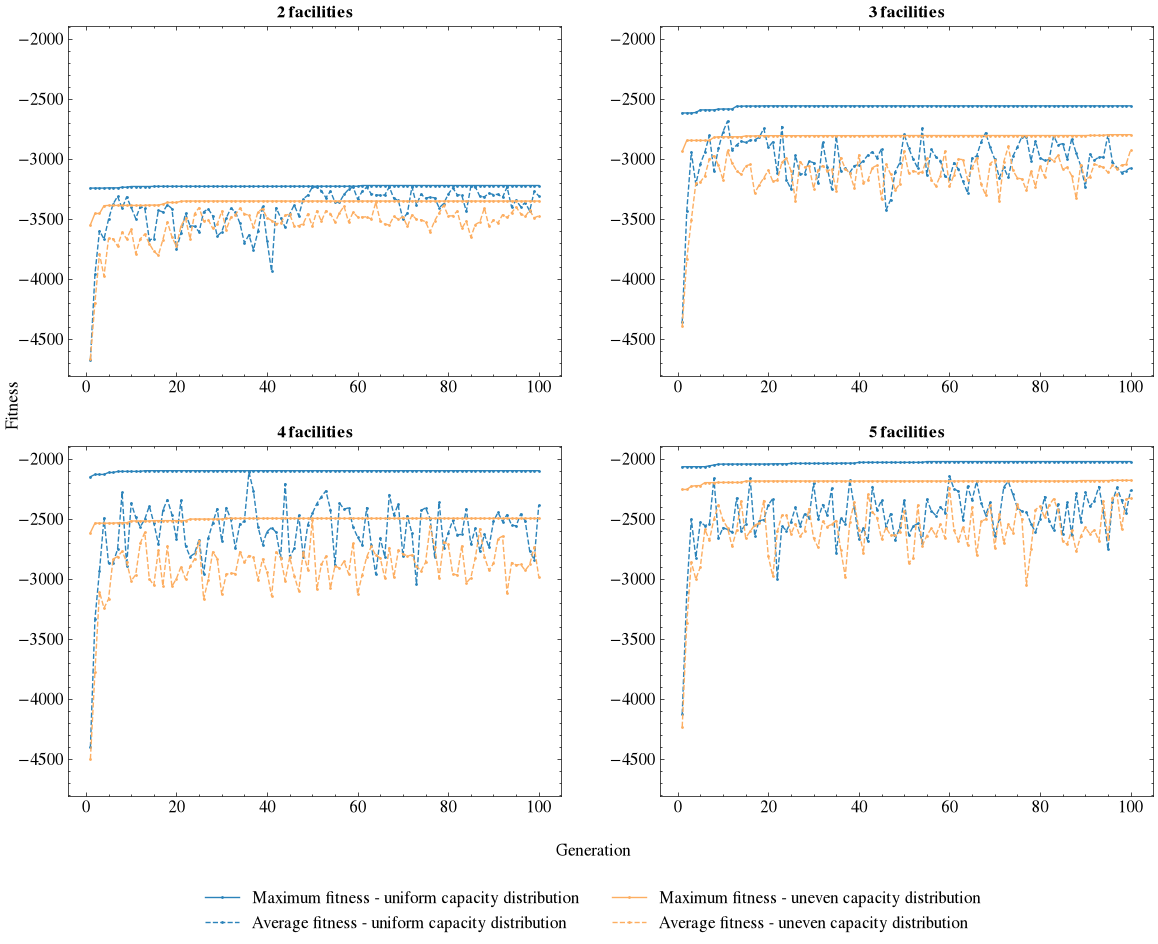

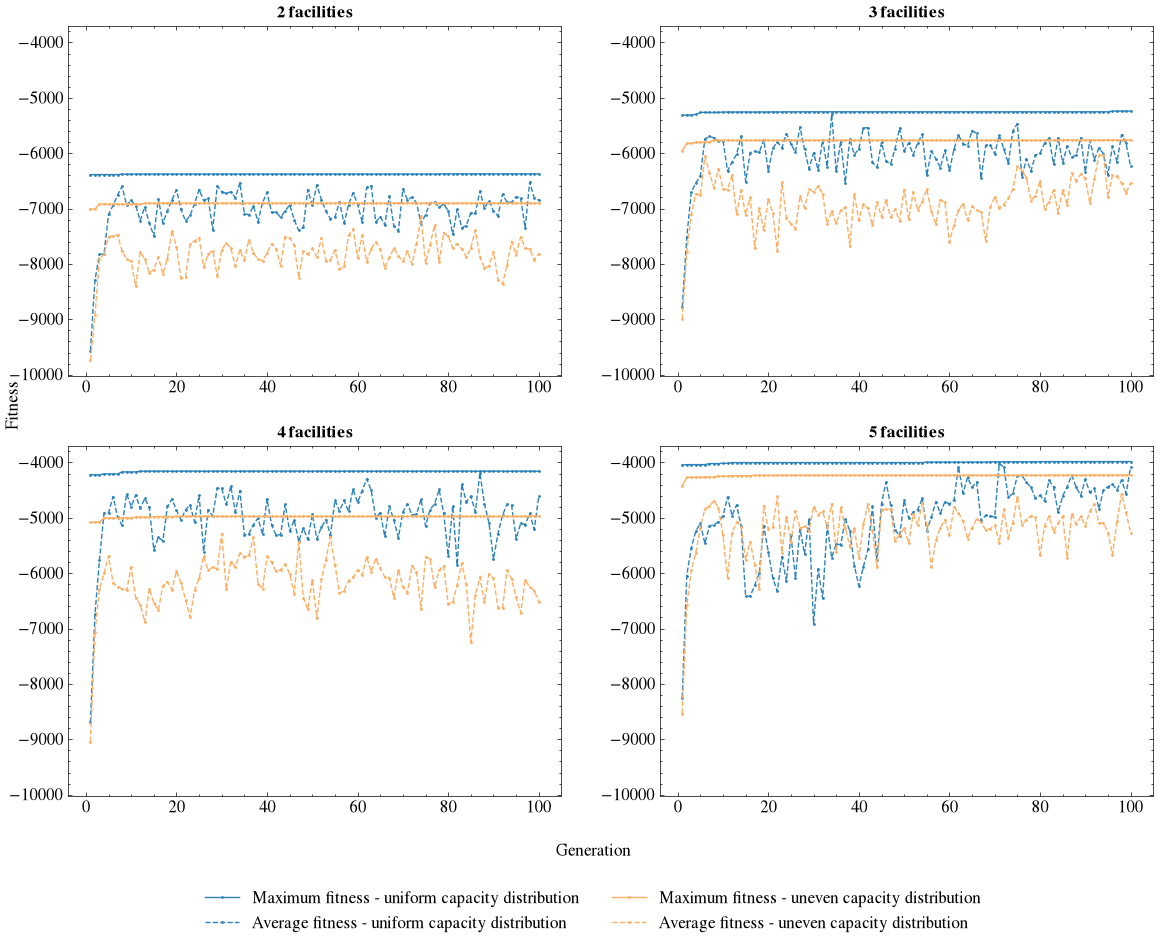

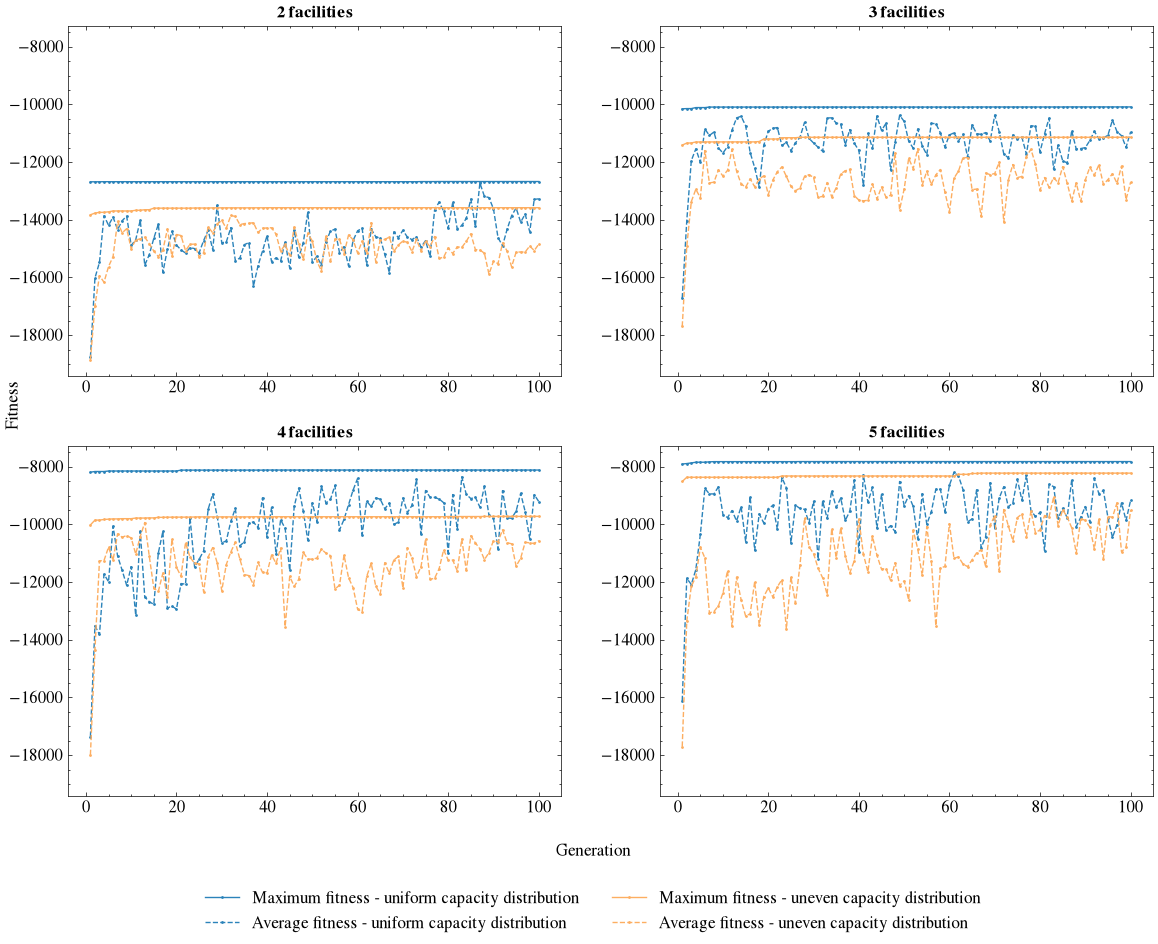

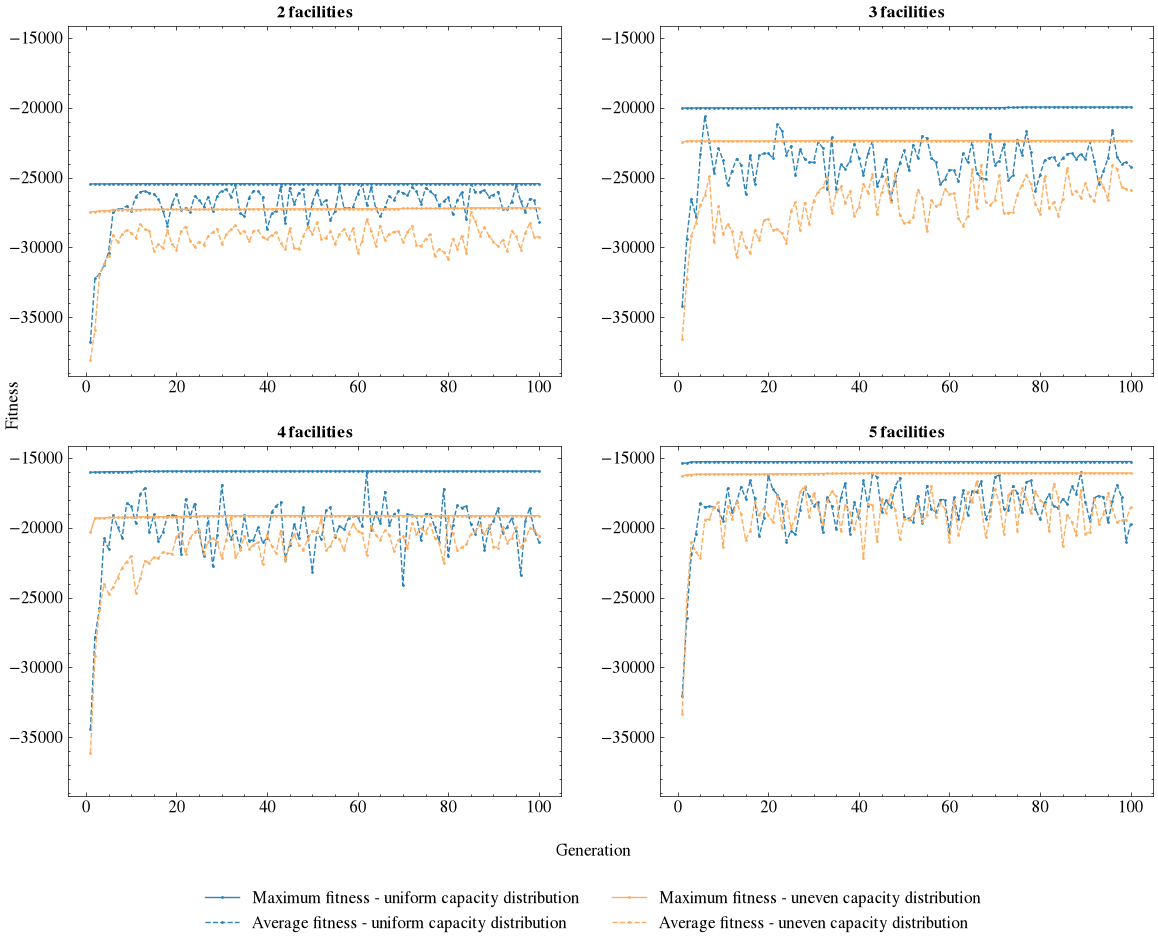

In [5]:
def gp_plot(num_customers):

    # Requisitos para exportar em PDF
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    # Cria o gráfico de evolução
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

    num_warehouses_options = [2, 3, 4, 5]
    capacity_distribution_options = ['uniform', 'uneven']

    colors = get_colors(len(capacity_distribution_options))

    for ax, num_warehouses in zip(axes.flatten(), num_warehouses_options):
        for capacity_distribution in capacity_distribution_options:
            df = pd.read_csv(f'training/genetic_programming_training/gp_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_best_individuals.csv')
            grouped_df = df.groupby('generation').agg({'max_fitness': 'mean', 'avg_fitness': 'mean'}).reset_index()
            ax.plot(grouped_df['generation'], grouped_df['max_fitness'], marker='o', label=f'Maximum fitness - {capacity_distribution} capacity distribution', linestyle='solid', markersize=1, linewidth=1, color=colors[capacity_distribution_options.index(capacity_distribution)])
            ax.plot(grouped_df['generation'], grouped_df['avg_fitness'], marker='o', label=f'Average fitness - {capacity_distribution} capacity distribution', linestyle='dashed', markersize=1, linewidth=1, color=colors[capacity_distribution_options.index(capacity_distribution)])
        
        ax.set_title(f'{num_warehouses} facilities', fontweight='bold')
        ax.grid(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xticks([0, 20, 40, 60, 80, 100])
        ax.tick_params(axis='both', labelsize=FONT_SIZE_TICK, labelbottom=True, labelleft=True)

    # Set common labels
    fig.text(0.5, 0.05, 'Generation', ha='center', fontsize=FONT_SIZE_LABEL)
    fig.text(0.08, 0.5, 'Fitness', va='center', rotation='vertical', fontsize=FONT_SIZE_LABEL)

    # Add a shared legend
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=2, fontsize=FONT_SIZE_LEGEND)

    # Store the plot in a jpg file
    plt.savefig(f'training/genetic_programming_training/plots/gp_c_{num_customers}.pdf', dpi=600, bbox_inches='tight')

    # Exibe o gráfico
    #plt.show()

for num_customers in num_customers_options:
    gp_plot(num_customers)

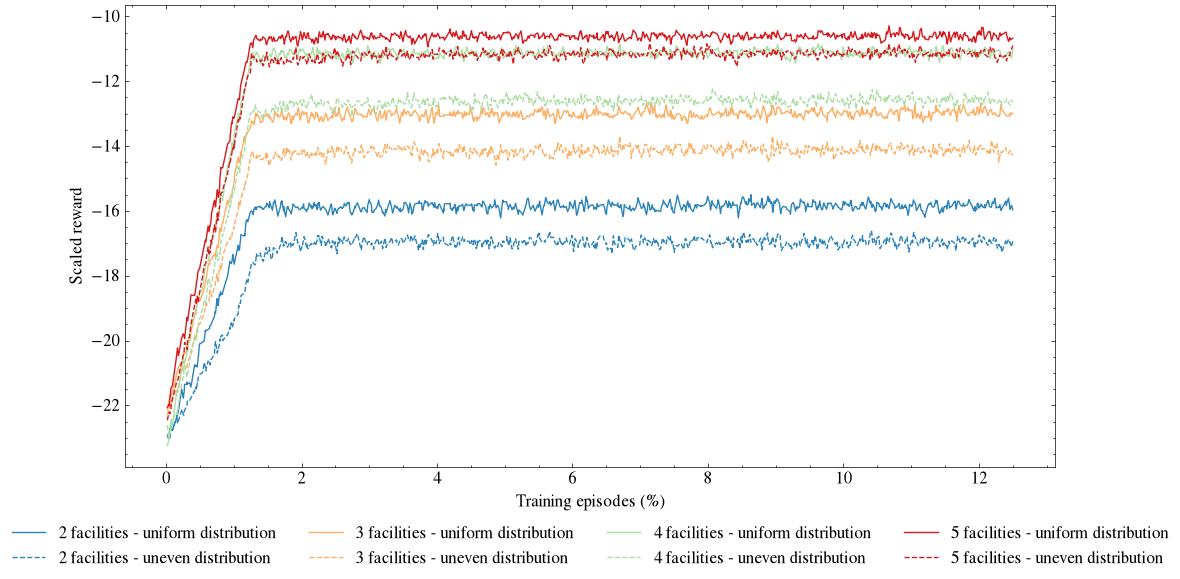

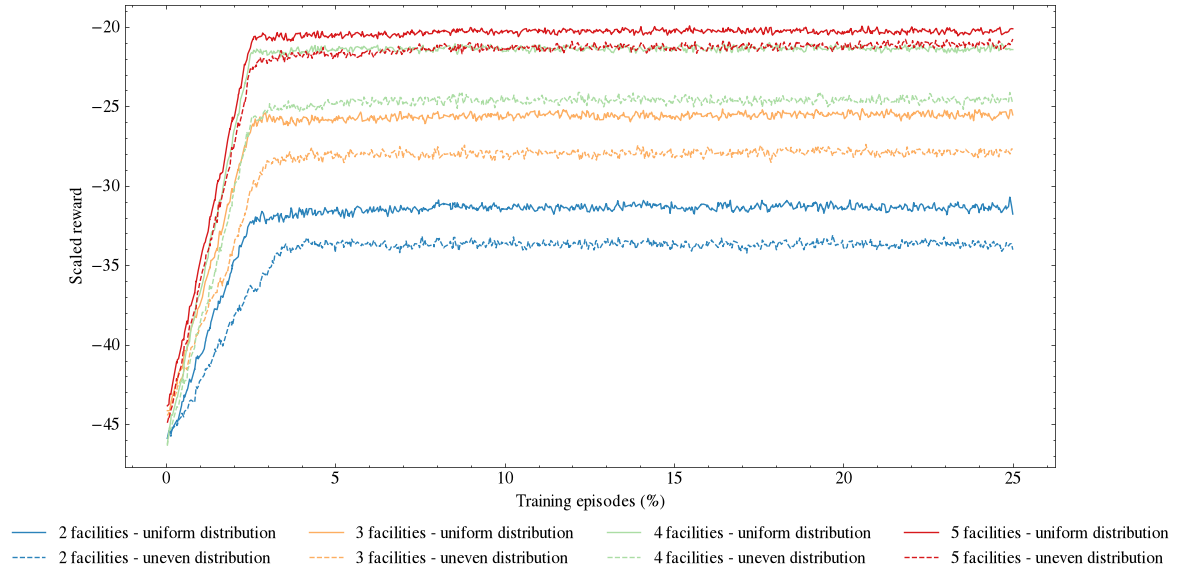

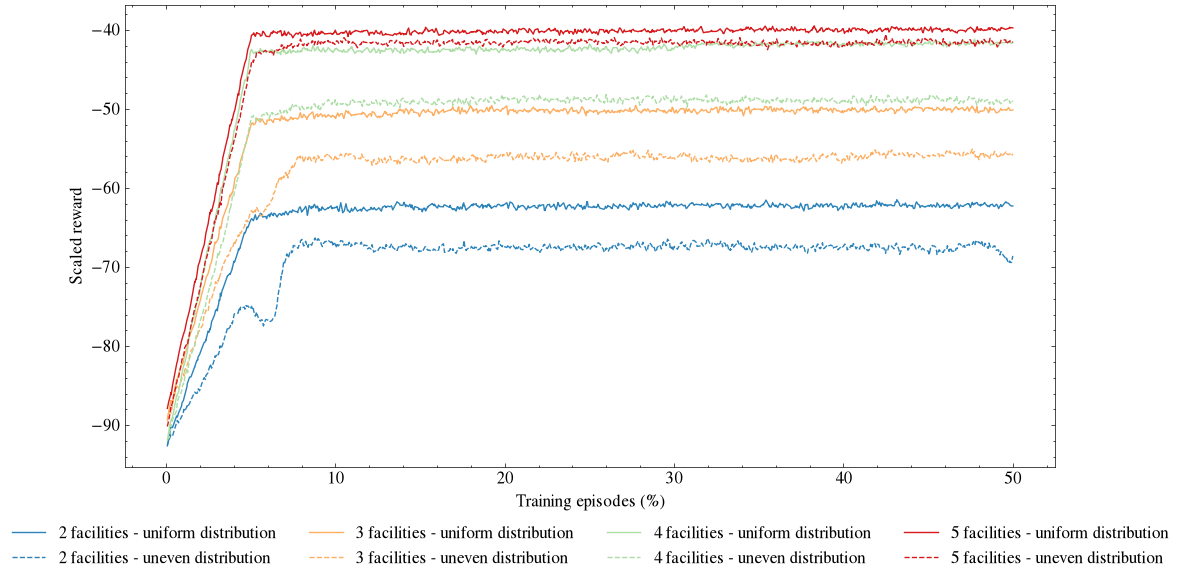

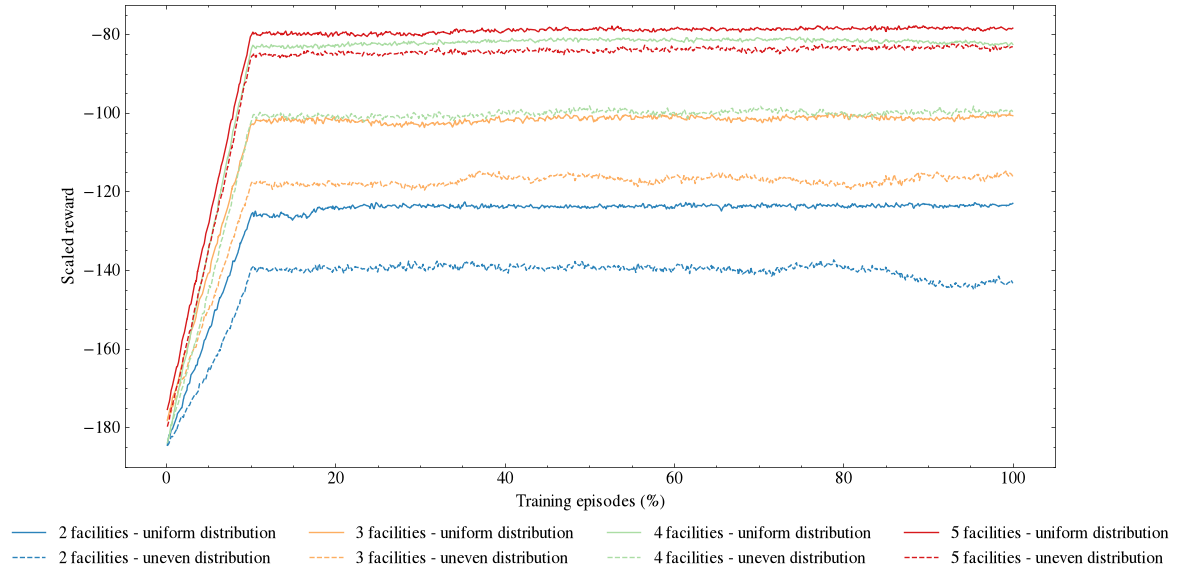

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Warehouse count -> color (COLOR_PALETTE) and capacity distribution -> linestyle, defined
# below once num_warehouses_options is available.

data = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0  # 0 = raw reward (no smoothing), up to 0.99 = heaviest smoothing (TensorBoard-style EMA)

# Read files and extract relevant data
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:

        n_steps = num_customers * 50_000  # Assuming n_steps is 10 times the number of customers
        for capacity_distribution in capacity_distribution_options:
            filename = f"training/deep_q_networks_training/reward_evolution/DQN_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_DQN_1.csv"
            
            df = pd.read_csv(filename)
            df = df.sort_values(by='Step')  # Ensure data is sorted by step
            
            if num_customers not in data:
                data[num_customers] = []
            
            data[num_customers].append({
                "warehouses": num_warehouses,
                "distribution": capacity_distribution,
                "df": df
            })

# Warehouse count -> color, capacity distribution -> linestyle (colorblind- and
# greyscale-safe: distinguishable by hue AND by dash pattern)
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

# Plot each graph for different customer counts
for num_customers, datasets in data.items():
    plt.figure(figsize=(12, 6))
    
    for entry in datasets:
        color = warehouse_colors[entry["warehouses"]]
        linestyle = distribution_linestyles[entry["distribution"]]

        smoothed_values = smooth_curve(entry["df"]["Value"].to_numpy(), SMOOTHING)

        plt.plot(entry["df"]["Step"] / n_steps * 100, smoothed_values,
                 label=f'{entry["warehouses"]} facilities - {entry["distribution"]} distribution',
                 color=color, linestyle=linestyle)
    plt.xlabel("Training episodes (%)", fontsize=FONT_SIZE_LABEL)
    plt.ylabel("Scaled reward", fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=FONT_SIZE_LEGEND)
    plt.grid(False)

    # Save figure
    plt.savefig(f"training/deep_q_networks_training/plots/dqn_reward_evolution_orders_{num_customers}.pdf", bbox_inches='tight', dpi=600)

    #plt.show()


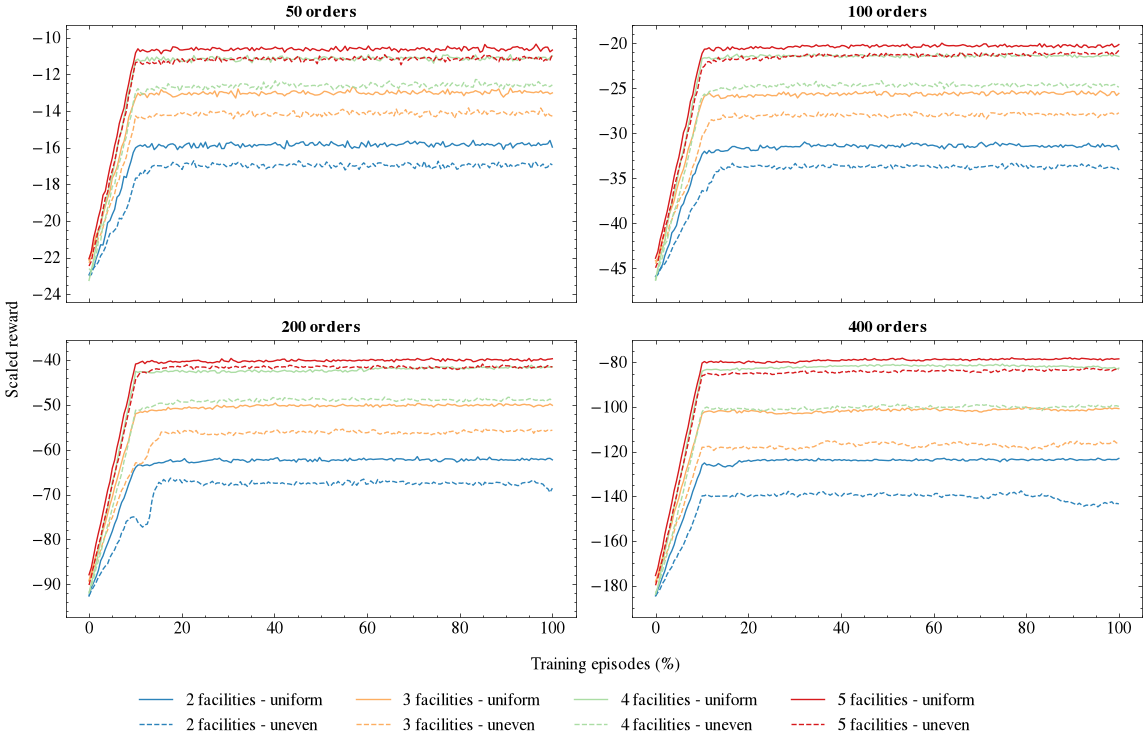

In [7]:
# Build pooled curves for one single figure
curves = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0

for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        n_steps = num_customers * 50_000
        for capacity_distribution in capacity_distribution_options:
            filename = (
                f"training/deep_q_networks_training/reward_evolution/"
                f"DQN_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_DQN_1.csv"
            )

            df = pd.read_csv(filename).sort_values(by="Step")
            x = df["Step"].to_numpy() / n_steps * 100
            y = np.array(smooth_curve(df["Value"].to_numpy(), SMOOTHING))

            x_grid = np.linspace(0, 100, 200)
            y_interp = np.interp(x_grid, x, y)

            curves.setdefault((num_customers, num_warehouses, capacity_distribution), []).append(y_interp)

# Same color code as the cell above
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = np.atleast_1d(axes).flatten()
x_grid = np.linspace(0, 100, 200)

for ax, num_customers in zip(axes, num_customers_options):
    y_min, y_max = np.inf, -np.inf

    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            ys = curves.get((num_customers, num_warehouses, capacity_distribution), [])
            if not ys:
                continue

            y_mean = np.mean(np.vstack(ys), axis=0)
            y_min = min(y_min, np.min(y_mean))
            y_max = max(y_max, np.max(y_mean))

            ax.plot(
                x_grid,
                y_mean,
                label=f"{num_warehouses} facilities - {capacity_distribution}",
                color=warehouse_colors[num_warehouses],
                linestyle=distribution_linestyles[capacity_distribution],
            )

    ax.set_title(f"{num_customers} orders", fontweight="bold")
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
    ax.set_ylim(y_min * 1.05, y_max * 0.9)

fig.text(0.54, 0.10, "Training episodes (%)", ha="center", fontsize=FONT_SIZE_LABEL)
fig.text(0.04, 0.5, "Scaled reward", va="center", rotation="vertical", fontsize=FONT_SIZE_LABEL)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=FONT_SIZE_LEGEND_TITLE,
)

plt.tight_layout(rect=[0.05, 0.12, 1, 0.95])
plt.savefig(
    "training/deep_q_networks_training/plots/dqn_reward_evolution_all.pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()


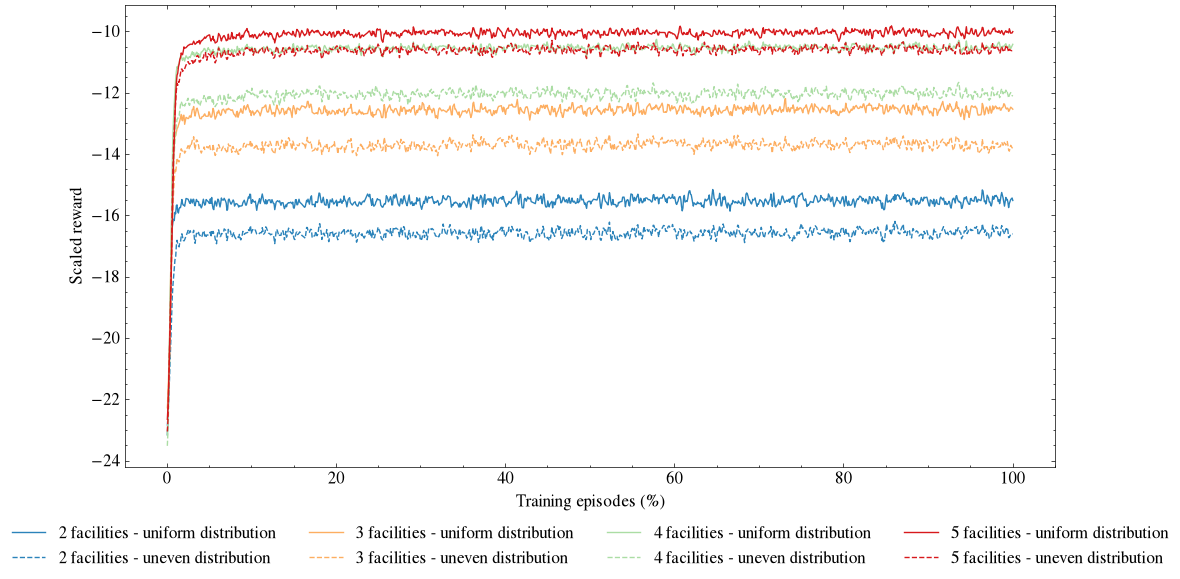

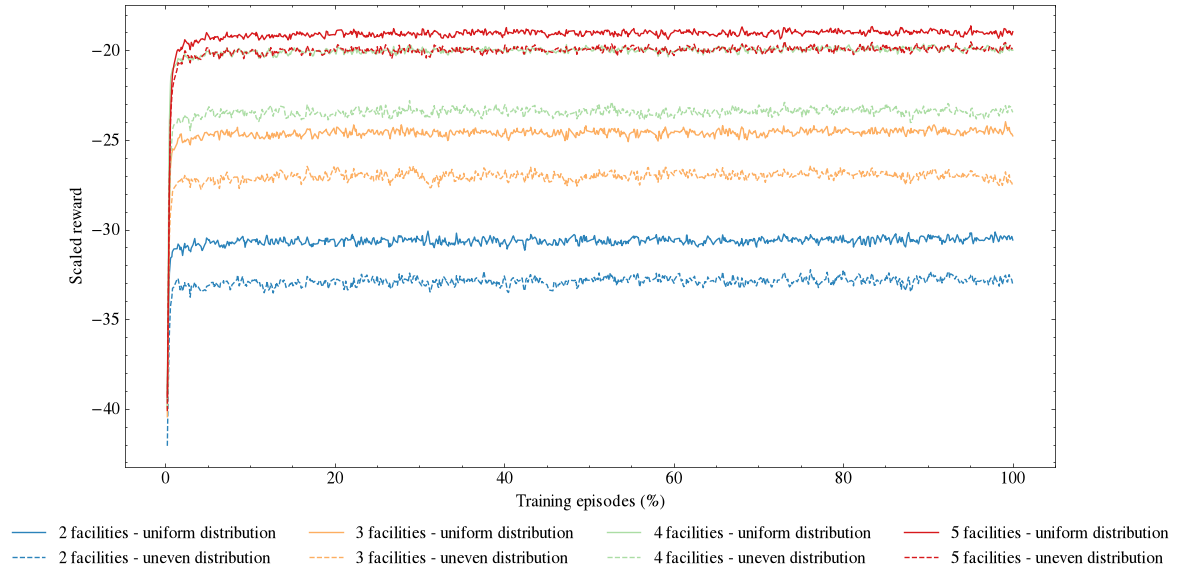

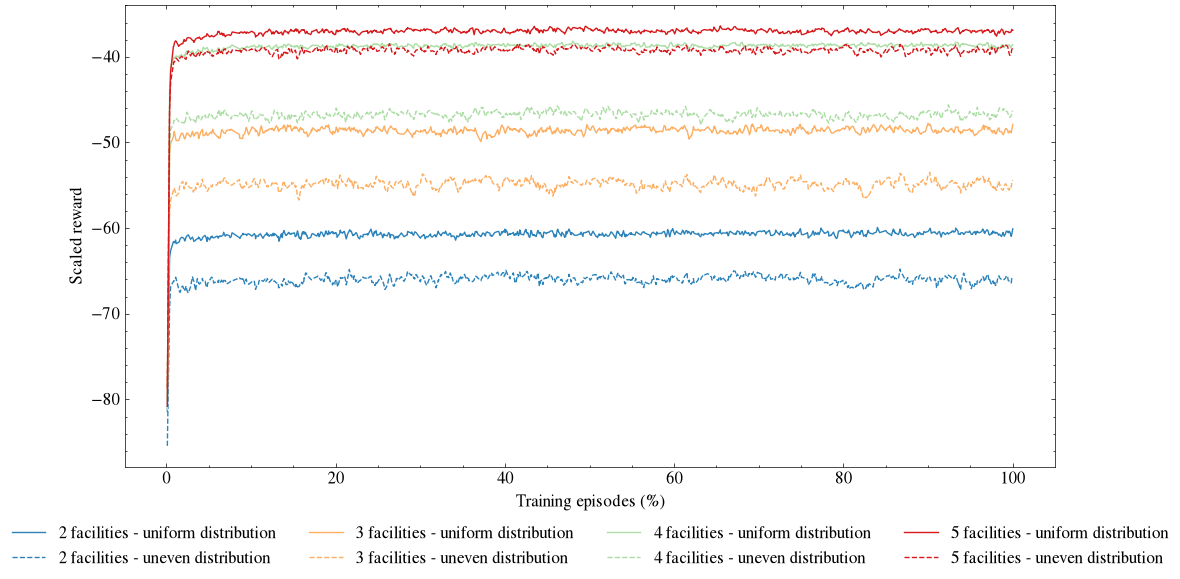

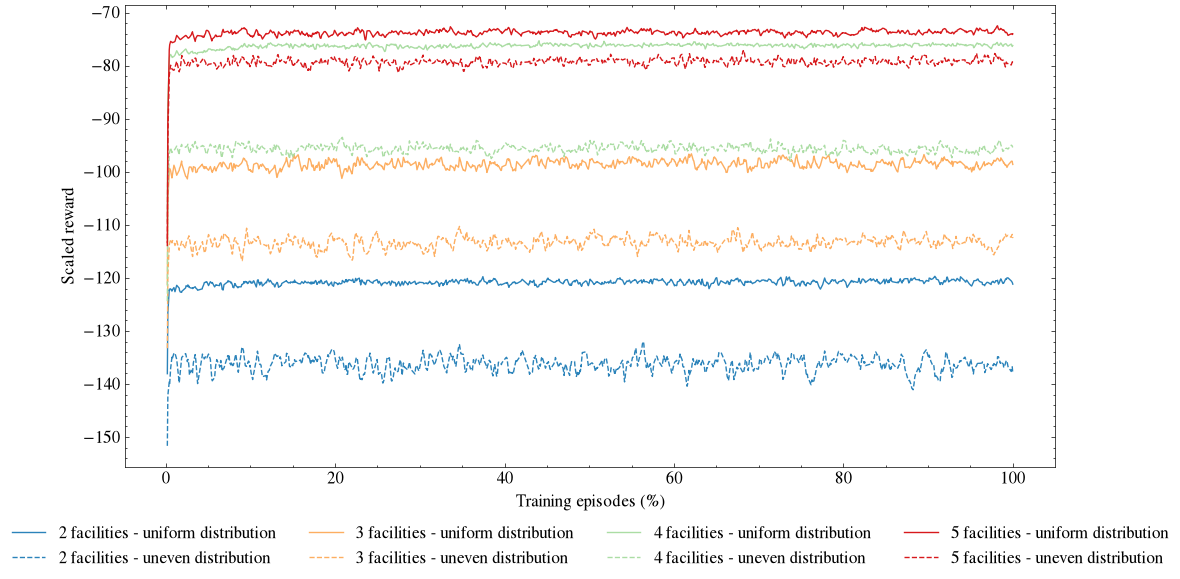

In [8]:
data = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0  # 0 = raw reward (no smoothing), up to 0.99 = heaviest smoothing (TensorBoard-style EMA)

# Read files and extract relevant data
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:

        n_steps = num_customers * 50_000  # Assuming n_steps is 10 times the number of customers
        for capacity_distribution in capacity_distribution_options:
            filename = f"training/proximal_policy_optimization_training/reward_evolution/PPO_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_MaskablePPO_1.csv"
            
            df = pd.read_csv(filename)
            df = df.sort_values(by='Step')  # Ensure data is sorted by step
            
            if num_customers not in data:
                data[num_customers] = []
            
            data[num_customers].append({
                "warehouses": num_warehouses,
                "distribution": capacity_distribution,
                "df": df
            })

# Warehouse count -> color, capacity distribution -> linestyle (colorblind- and
# greyscale-safe: distinguishable by hue AND by dash pattern)
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

# Plot each graph for different customer counts
for num_customers, datasets in data.items():

    n_steps = num_customers * 50_000  # Assuming n_steps is 10 times the number of customers
    
    plt.figure(figsize=(12, 6))
    
    for entry in datasets:
        color = warehouse_colors[entry["warehouses"]]
        linestyle = distribution_linestyles[entry["distribution"]]

        smoothed_values = smooth_curve(entry["df"]["Value"].to_numpy(), SMOOTHING)

        plt.plot(entry["df"]["Step"] / n_steps * 100, smoothed_values,
                 label=f'{entry["warehouses"]} facilities - {entry["distribution"]} distribution',
                 color=color, linestyle=linestyle)
    plt.xlabel("Training episodes (%)", fontsize=FONT_SIZE_LABEL)
    plt.ylabel("Scaled reward", fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=FONT_SIZE_LEGEND)
    plt.grid(False)

    # Save figure
    plt.savefig(f"training/proximal_policy_optimization_training/plots/ppo_reward_evolution_orders_{num_customers}.pdf", bbox_inches='tight', dpi=600)

    #plt.show()

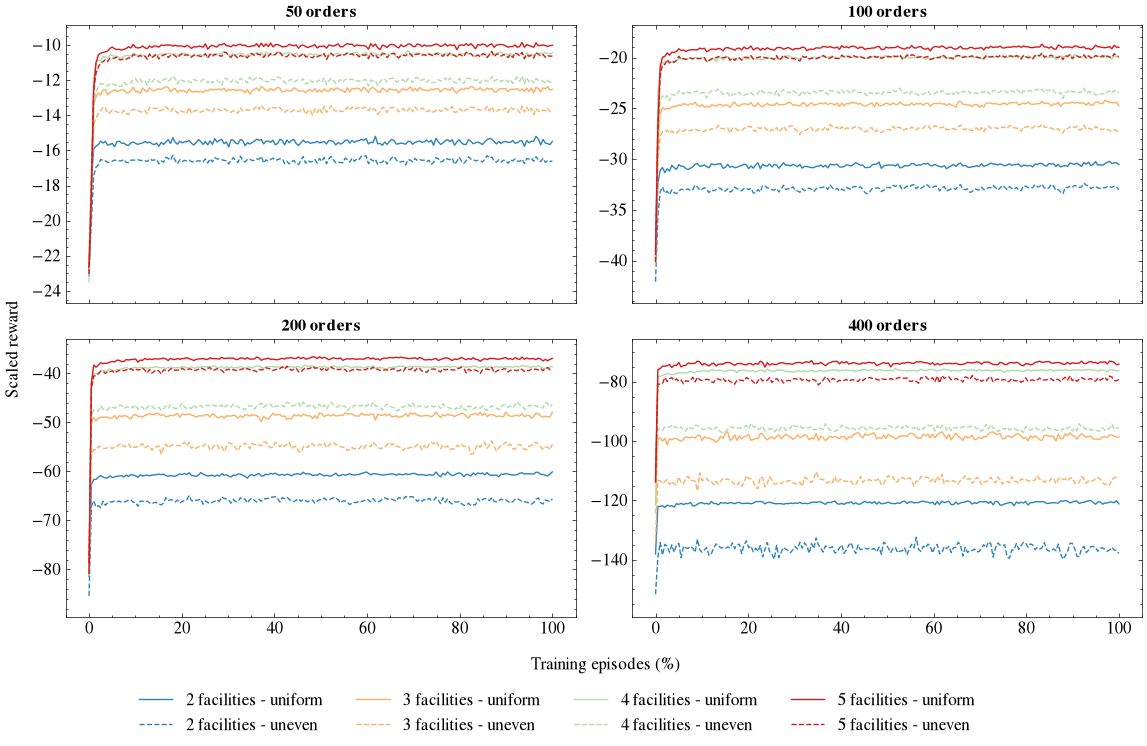

In [9]:
# Build pooled curves for one single figure
curves = {}

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ["uniform", "uneven"]

SMOOTHING = 0

for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        n_steps = num_customers * 50_000
        for capacity_distribution in capacity_distribution_options:
            filename = (
                f"training/proximal_policy_optimization_training/reward_evolution/"
                f"PPO_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}_MaskablePPO_1.csv"
            )

            df = pd.read_csv(filename).sort_values(by="Step")
            x = df["Step"].to_numpy() / n_steps * 100
            y = np.array(smooth_curve(df["Value"].to_numpy(), SMOOTHING))

            x_grid = np.linspace(0, 100, 200)
            y_interp = np.interp(x_grid, x, y)

            curves.setdefault((num_customers, num_warehouses, capacity_distribution), []).append(y_interp)

# Same color code as the cell above
warehouse_colors = dict(zip(num_warehouses_options, get_colors(len(num_warehouses_options))))
distribution_linestyles = {"uniform": "-", "uneven": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = np.atleast_1d(axes).flatten()
x_grid = np.linspace(0, 100, 200)

for ax, num_customers in zip(axes, num_customers_options):
    y_min, y_max = np.inf, -np.inf

    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            ys = curves.get((num_customers, num_warehouses, capacity_distribution), [])
            if not ys:
                continue

            y_mean = np.mean(np.vstack(ys), axis=0)
            y_min = min(y_min, np.min(y_mean))
            y_max = max(y_max, np.max(y_mean))

            ax.plot(
                x_grid,
                y_mean,
                label=f"{num_warehouses} facilities - {capacity_distribution}",
                color=warehouse_colors[num_warehouses],
                linestyle=distribution_linestyles[capacity_distribution],
            )

    ax.set_title(f"{num_customers} orders", fontweight="bold")
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
    ax.set_ylim(y_min * 1.05, y_max * 0.9)

fig.text(0.54, 0.10, "Training episodes (%)", ha="center", fontsize=FONT_SIZE_LABEL)
fig.text(0.04, 0.5, "Scaled reward", va="center", rotation="vertical", fontsize=FONT_SIZE_LABEL)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    fontsize=FONT_SIZE_LEGEND,
    title_fontsize=FONT_SIZE_LEGEND_TITLE,
)

plt.tight_layout(rect=[0.05, 0.12, 1, 0.95])
plt.savefig(
    "training/proximal_policy_optimization_training/plots/ppo_reward_evolution_all.pdf",
    bbox_inches="tight",
    dpi=600,
)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


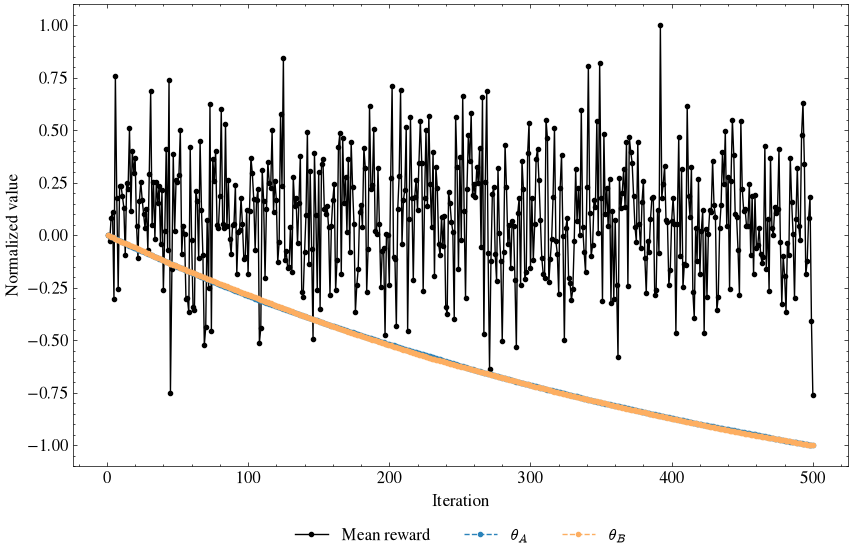

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


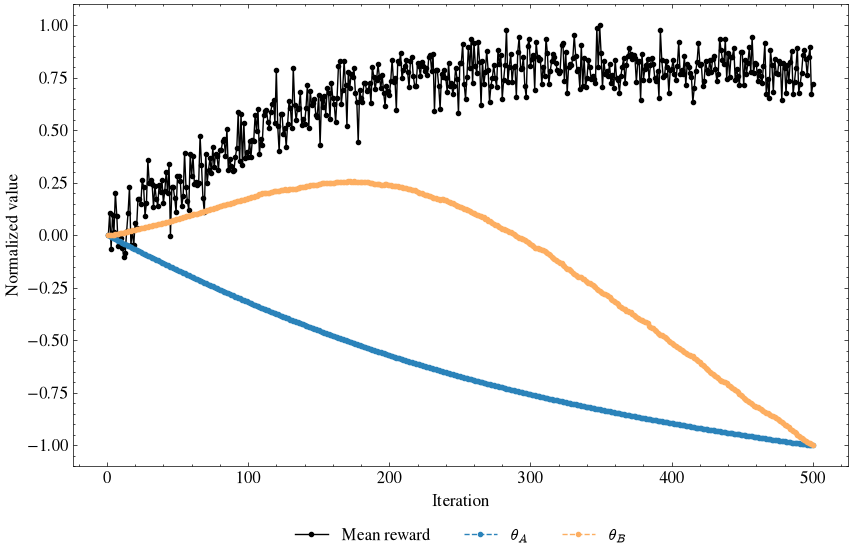

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


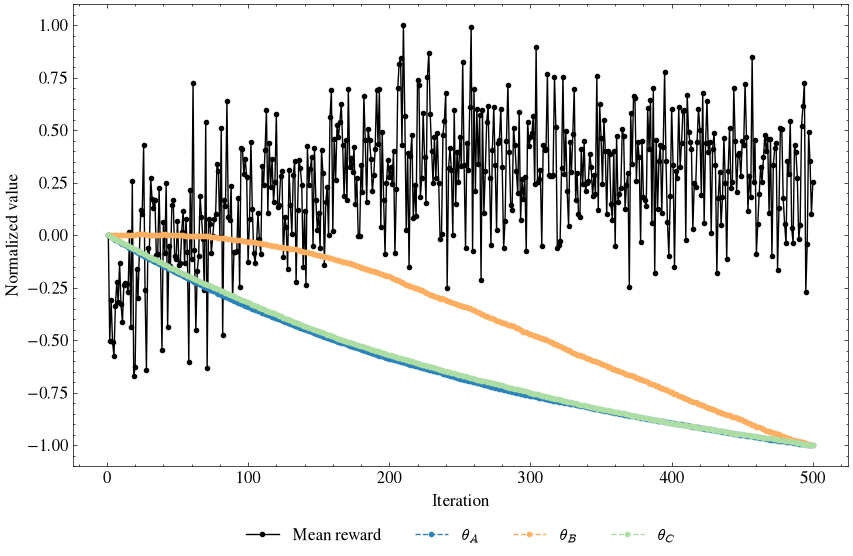

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


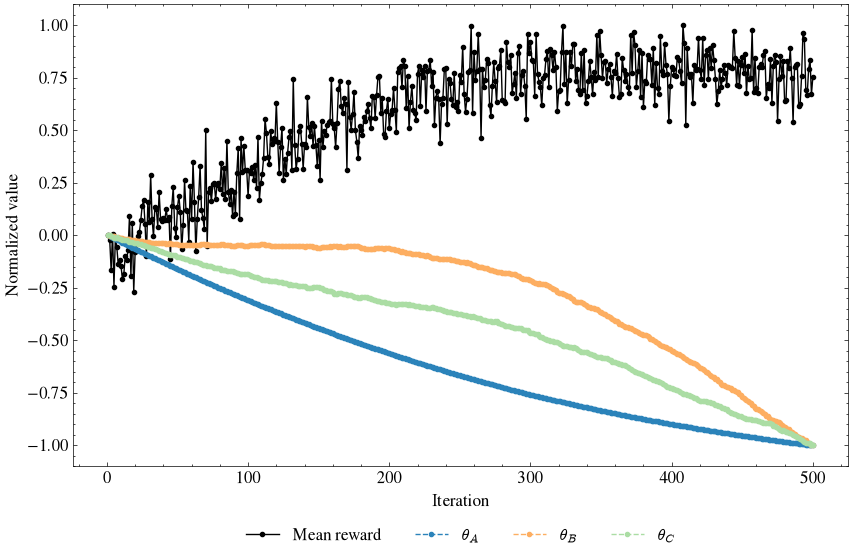

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


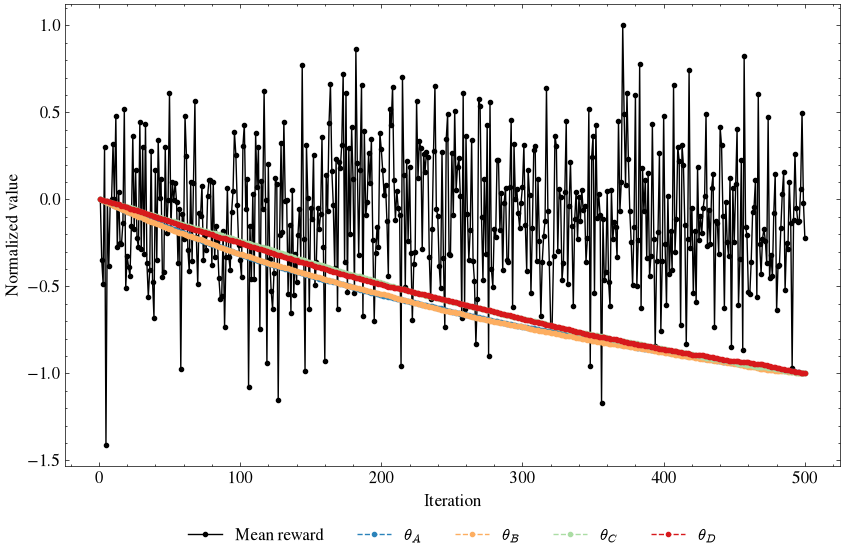

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


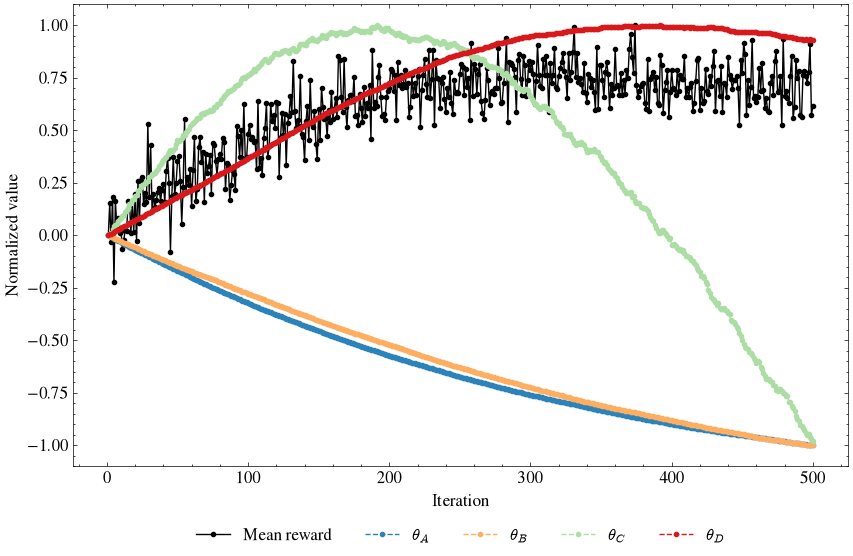

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


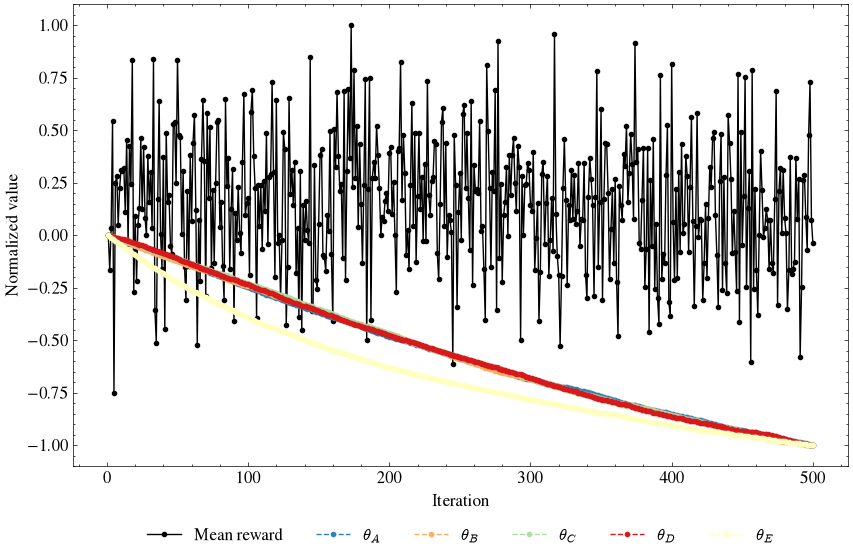

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


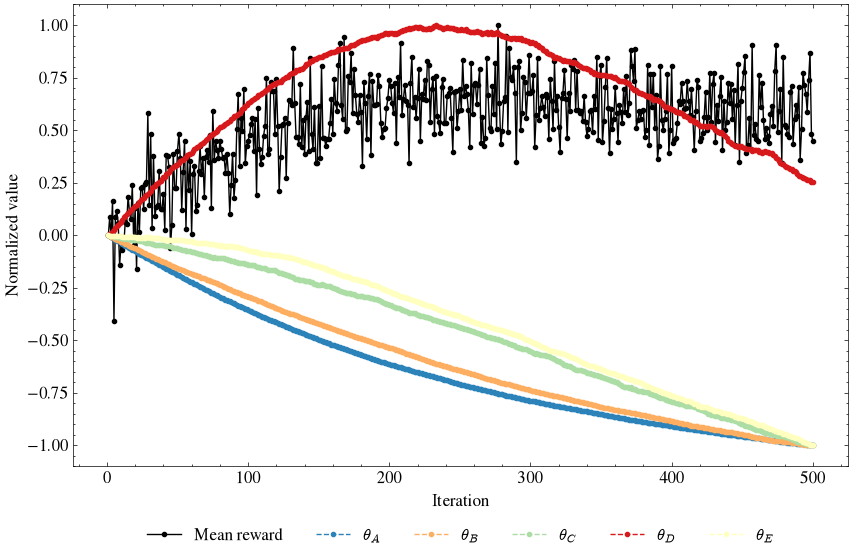

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


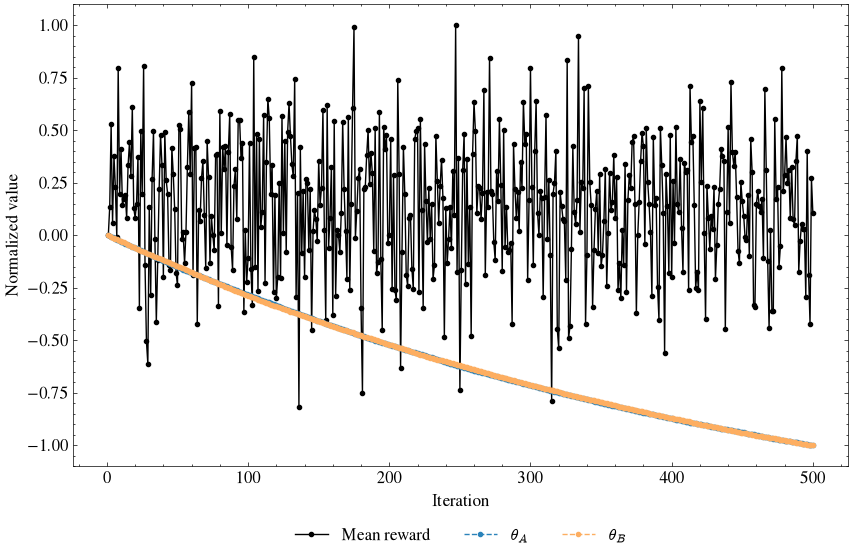

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


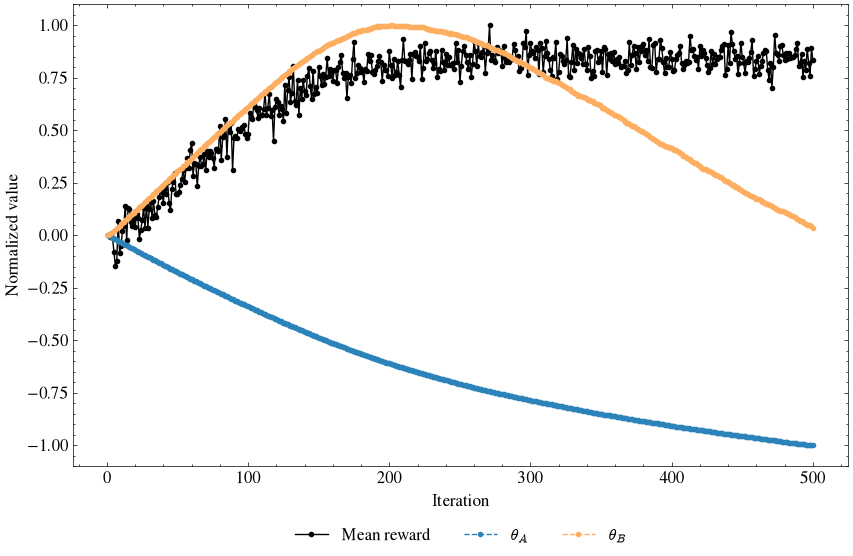

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


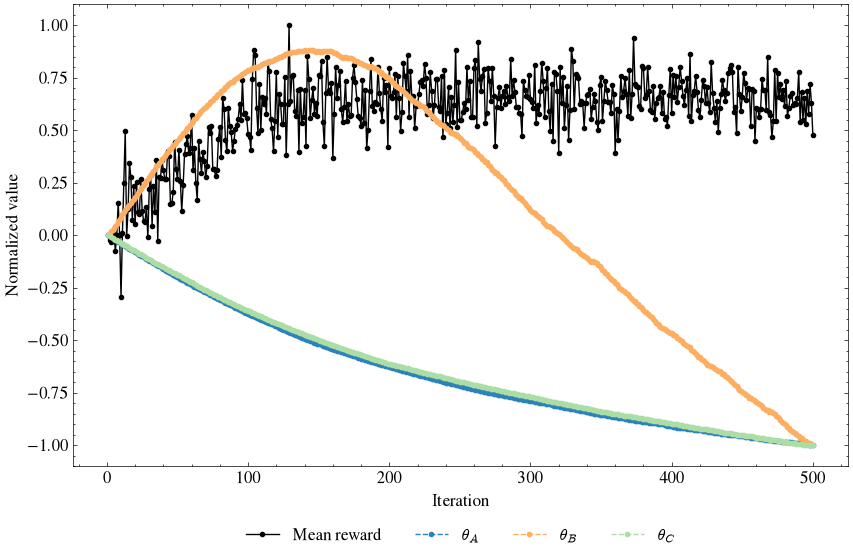

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


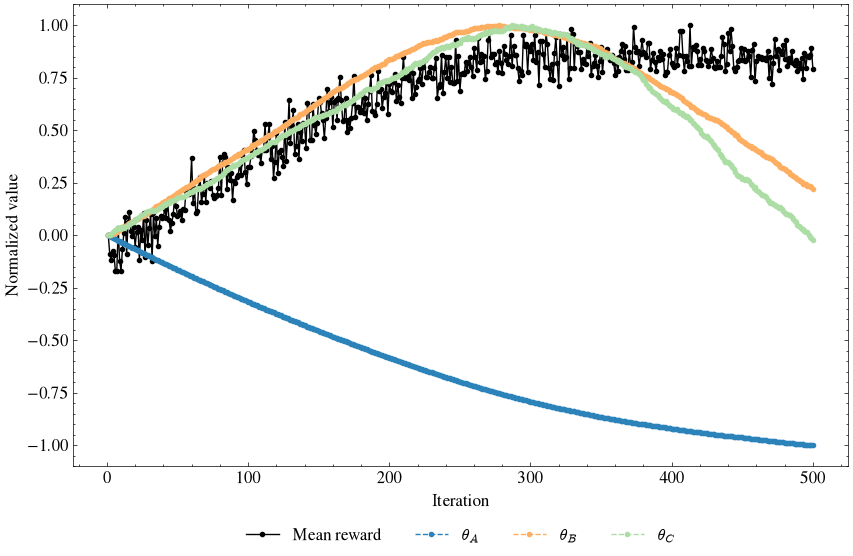

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


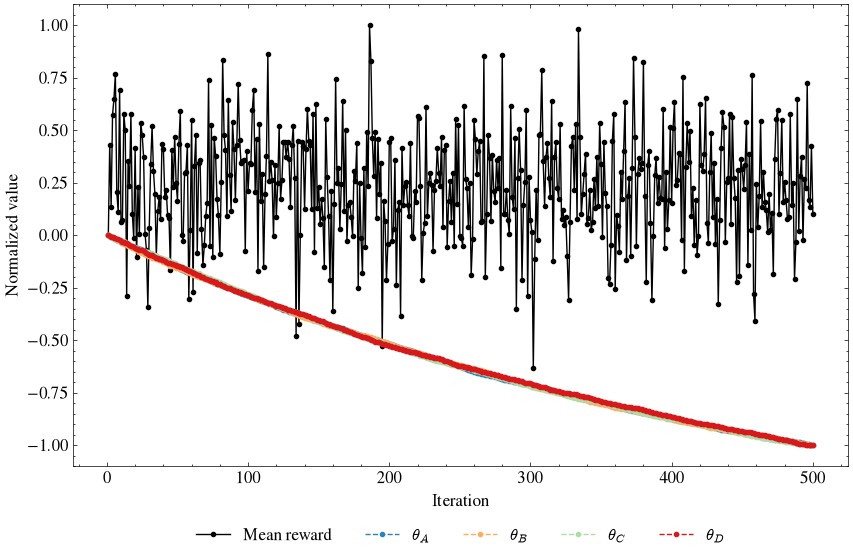

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


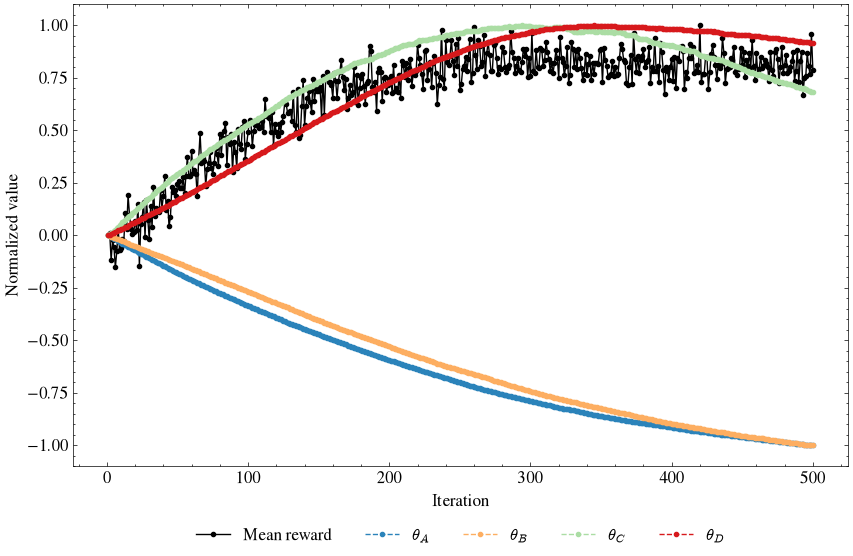

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


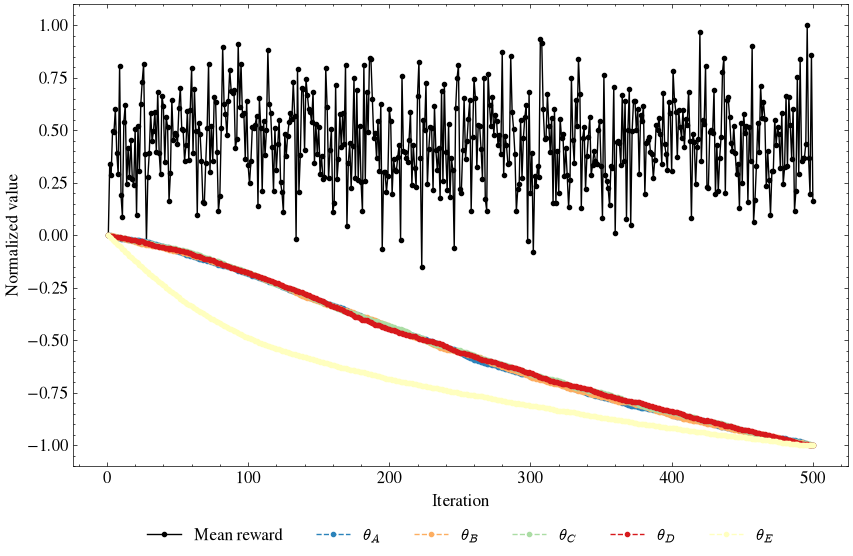

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


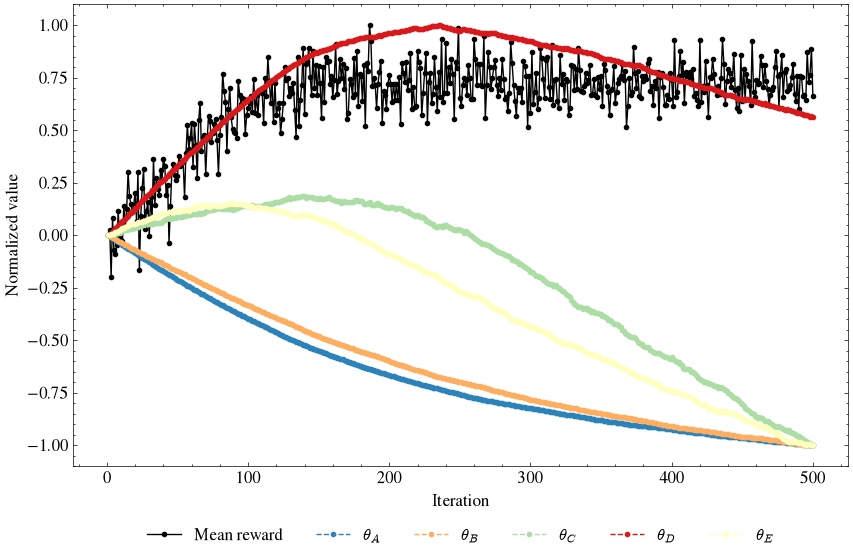

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


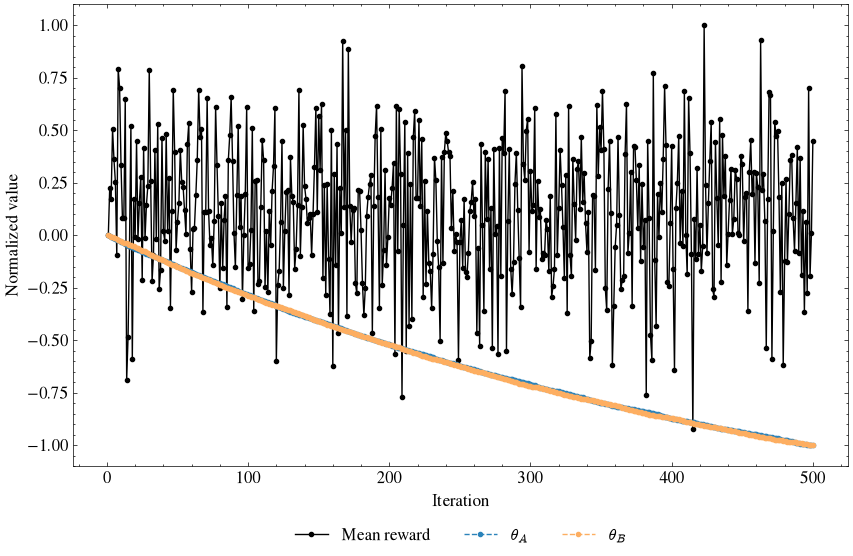

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


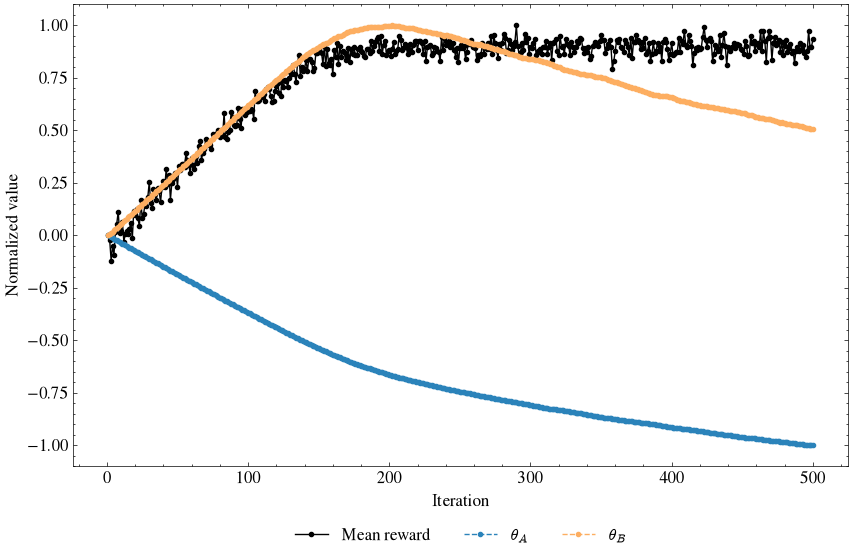

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


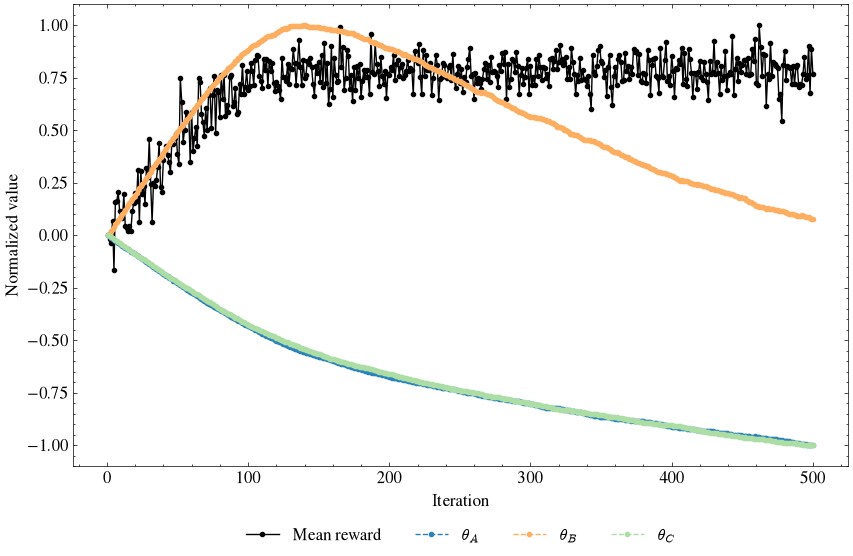

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


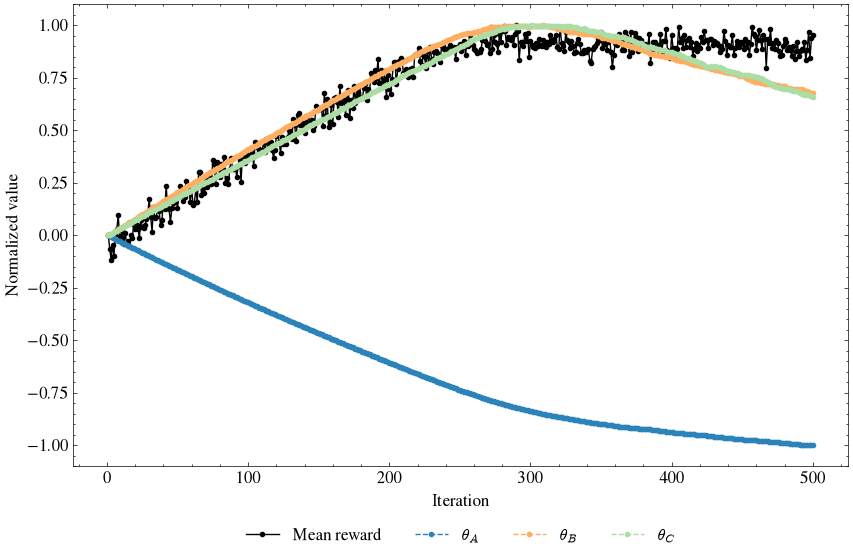

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


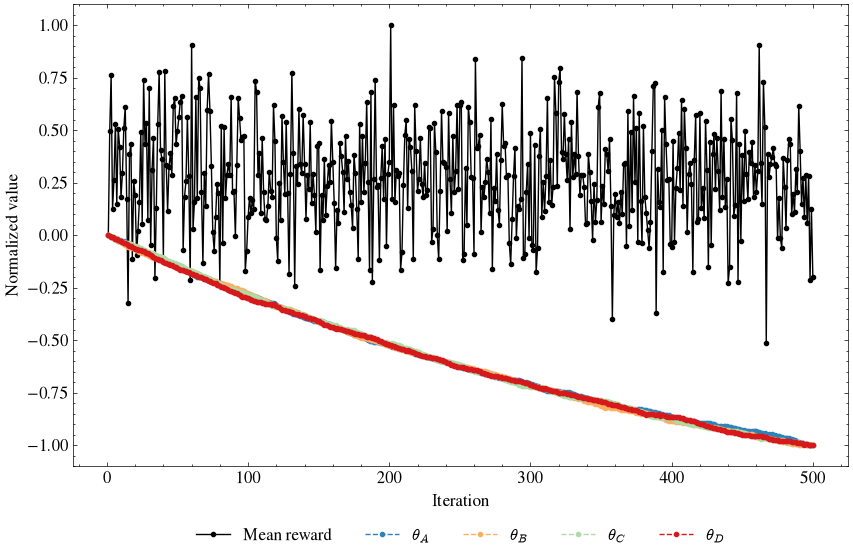

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


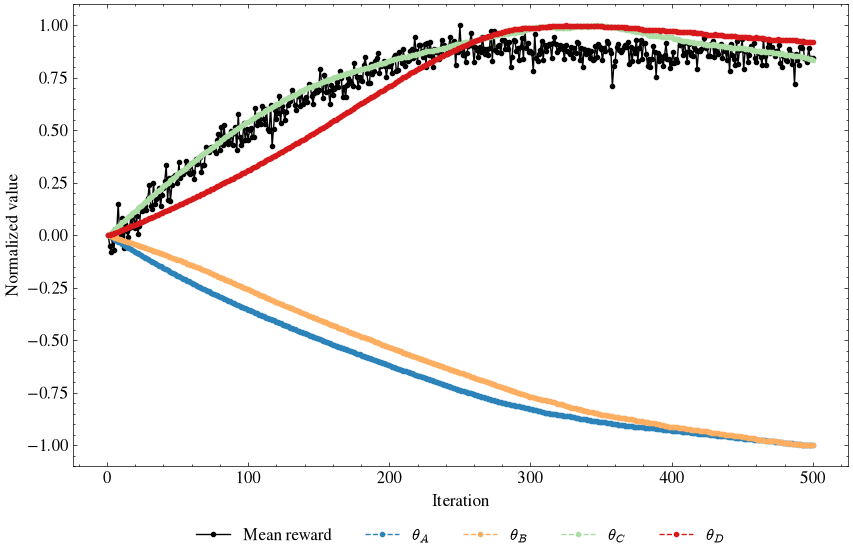

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


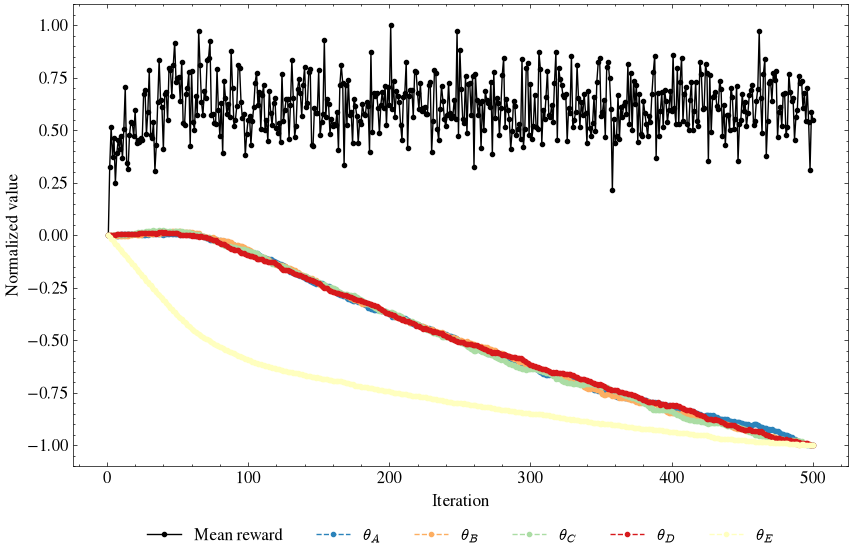

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


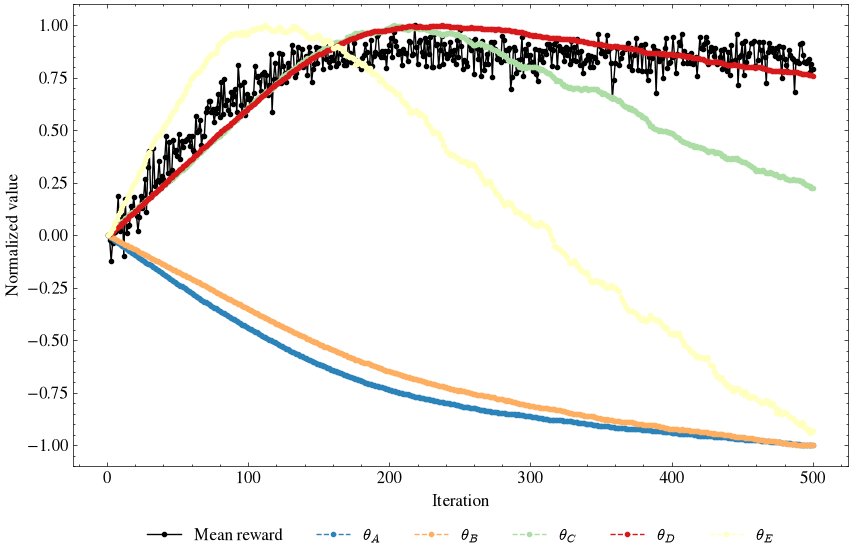

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


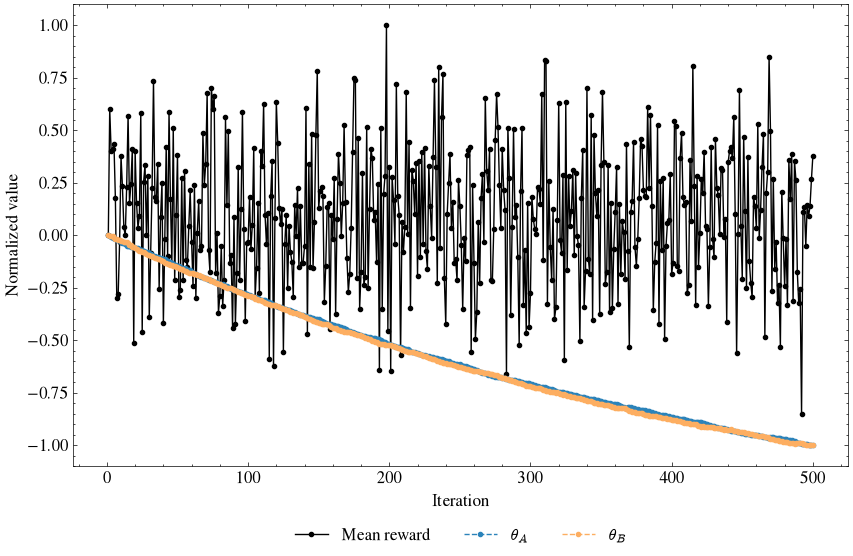

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


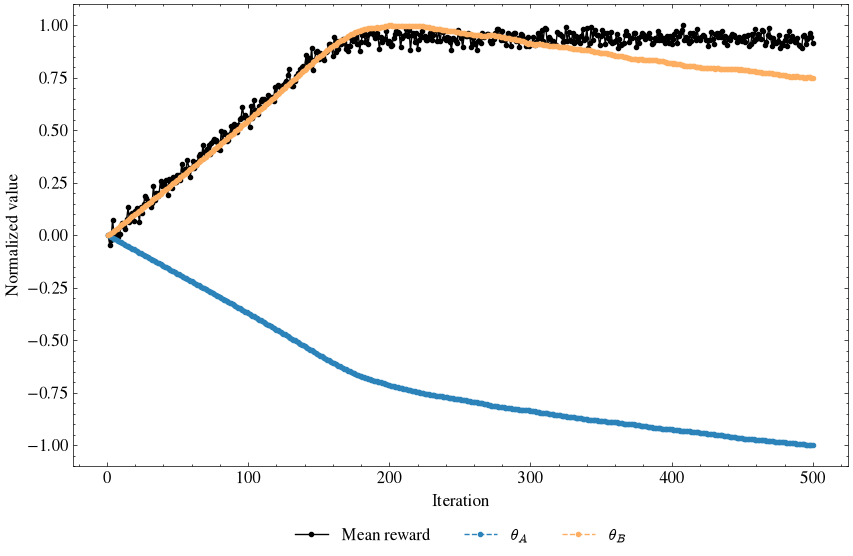

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


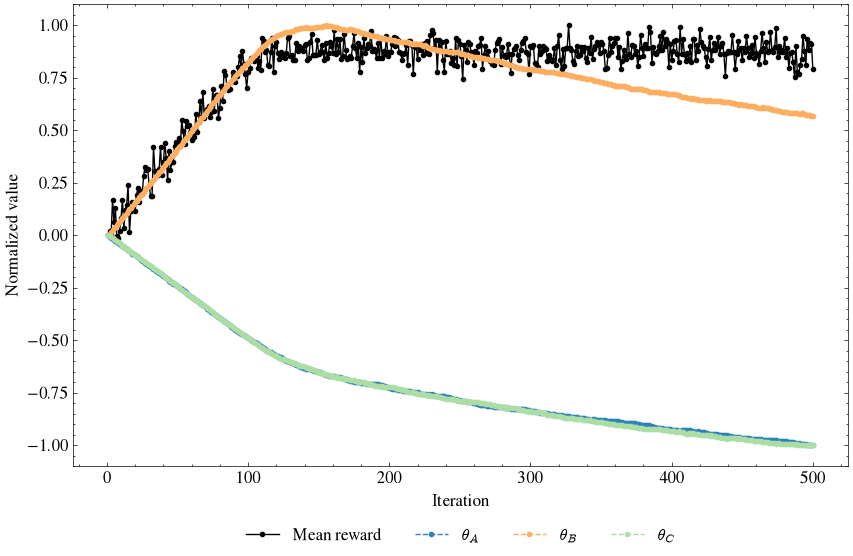

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


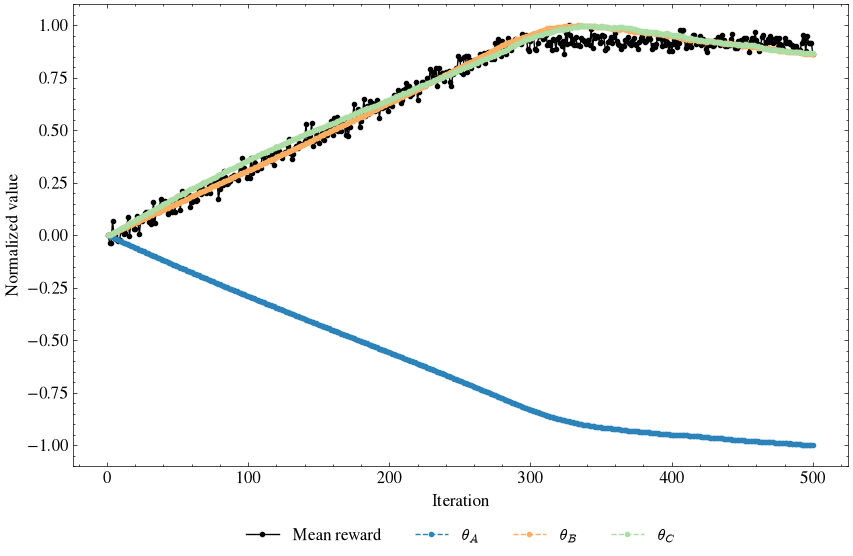

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


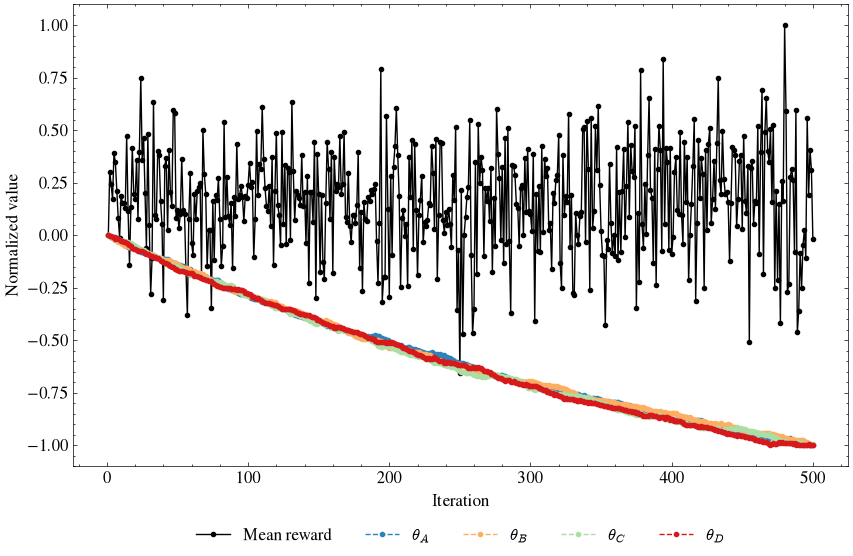

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


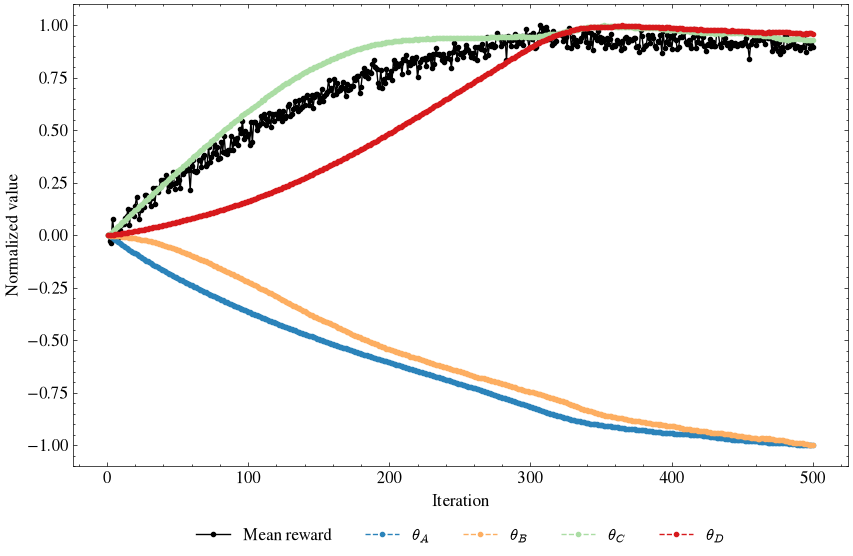

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


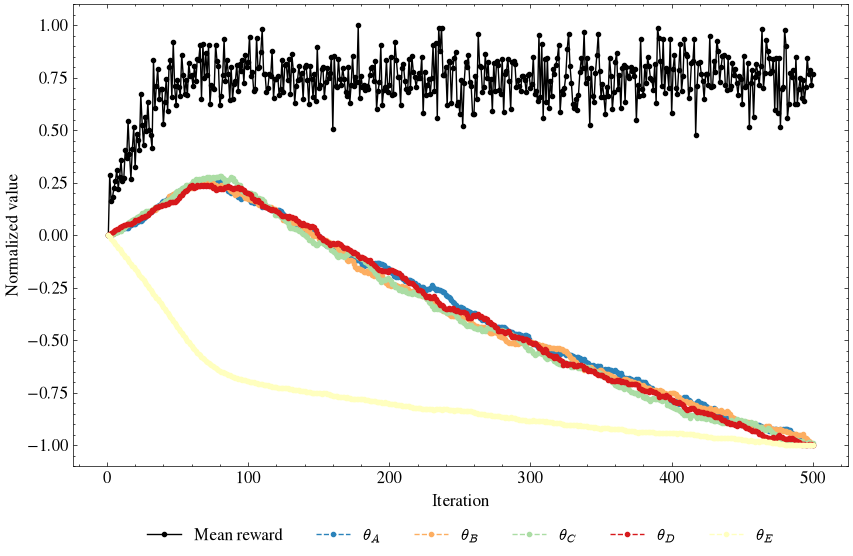

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


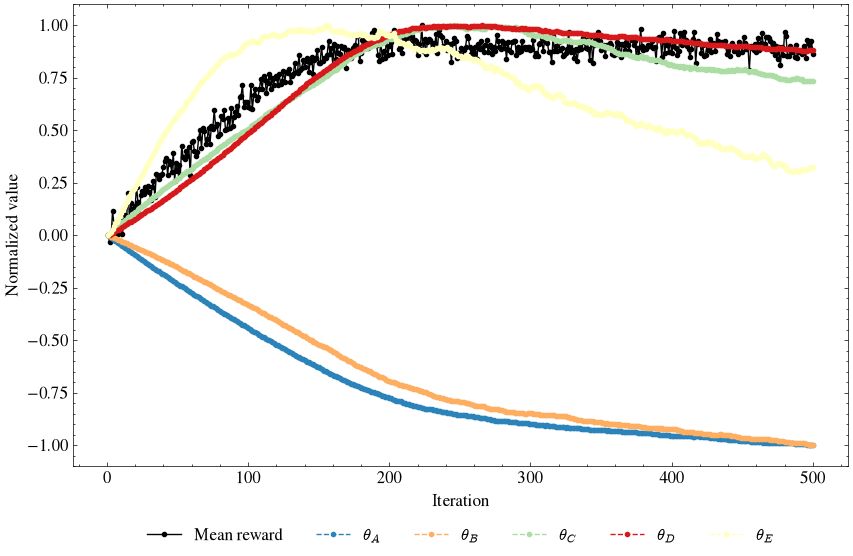

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def lvfa_plot(num_warehouses, num_customers, capacity_distribution, normalize=False, show_theta_convergence=False, show_reward= False):

    plt.figure(figsize=(10, 6))

    data = pd.read_csv(f'training/linear_value_function_approximation_training/lvfa_improved_evolution_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}.csv')

    if show_reward:
        mean_reward = data['mean_reward']
        max_reward = max(mean_reward)
        if normalize:
            first_reward = mean_reward.iloc[0]
            last_reward = mean_reward.iloc[-1]
            denom = max_reward - first_reward
            mean_reward = (mean_reward - first_reward) / denom

        # Plot the data - mean_reward stays a fixed neutral color so it visually stands
        # apart from the colormap-colored theta coefficient lines below.
        plt.plot(data['iteration'], mean_reward, marker='.', linestyle='-', color='black', label='Mean reward')

    if show_theta_convergence:
        # theta is stored as a comma-joined string per iteration; parse into an (iterations x coefficients) matrix
        theta_matrix = np.array([list(map(float, row.split(','))) for row in data['theta']])
        # normalize each coefficient by its own max absolute value across iterations, not by
        # the first iteration - theta starts at np.zeros() and is logged before the first
        # update in update_policy, so the first row is always all zeros and would divide by zero
        max_abs = np.max(np.abs(theta_matrix), axis=0)
        max_abs[max_abs == 0] = 1  # avoid dividing a coefficient that stays at 0 throughout
        normalized_theta = theta_matrix / max_abs

        theta_colors = get_colors(normalized_theta.shape[1])
        for coef_idx in range(normalized_theta.shape[1]):
            plt.plot(
                data['iteration'],
                normalized_theta[:, coef_idx],
                marker='.',
                linestyle='--',
                color=theta_colors[coef_idx],
                label=rf'$\theta_{{{chr(65 + coef_idx)}}}$'
            )

    plt.xlabel('Iteration', fontsize=FONT_SIZE_LABEL)
    plt.ylabel('Normalized value' if (normalize or show_theta_convergence) else 'Mean Reward', fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    if normalize or show_theta_convergence:
        plt.legend(fontsize=FONT_SIZE_LEGEND, loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=num_warehouses + (1 if show_reward else 0))
    #plt.title('Mean Reward over Iterations')
    plt.grid(False)

    # Save the plot
    out_dir = 'training/linear_value_function_approximation_training/plots'
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f'{out_dir}/lvfa_improved_evolution_w_{num_warehouses}_c_{num_customers}_{capacity_distribution}.pdf', dpi=600, bbox_inches='tight')

    plt.show()

num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

for num_customers in num_customers_options:
    for num_warehouses in num_warehouses_options:
        for capacity_distribution in capacity_distribution_options:
            #print(f"Plotting LVFA for {num_warehouses} warehouses, {num_customers} customers, {capacity_distribution} distribution")
            lvfa_plot(num_warehouses, num_customers, capacity_distribution, normalize=True, show_theta_convergence=True, show_reward=True)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


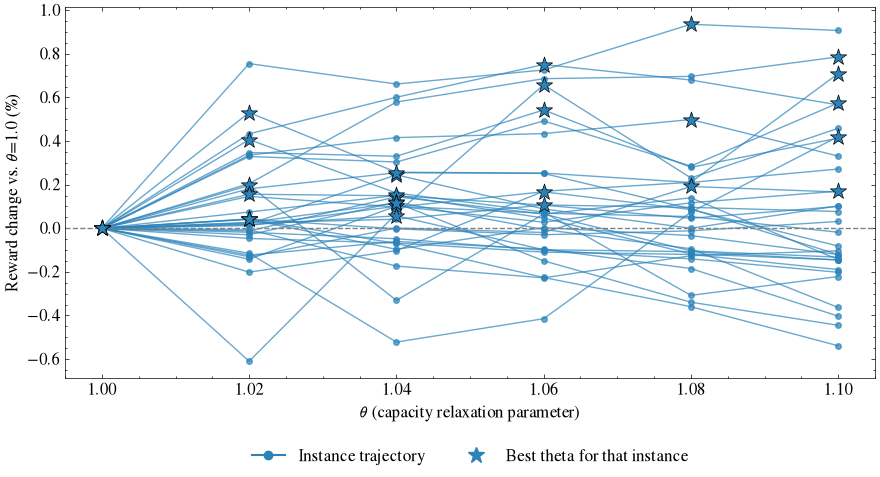

In [12]:
# PLA (parameterized lookahead approximation) sensitivity to theta, across every
# instance in the tuning dataset. Raw mean_reward magnitudes aren't comparable across
# instance sizes, so each instance's curve is normalized against its own theta=1.0
# value (the unparameterized DEL policy - see Eq. 23) before plotting them together.
# Maximization framing: higher (more positive) = better, mirroring the standard RL
# reward-maximization view. No color coding by instance dimension - every instance gets the
# same line color, distinguished only by its trajectory and its own best-theta marker.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

theta_df = pd.read_csv('training/parameterized_lookahead_approximation_training/parameterized_lookahead_approximation_all_params.csv')

# reward is negative total distance (Eq. 9) - normalize directly against |baseline|
# so a positive pct always means reward improved (baseline itself is negative).

instance_cols = ['num_warehouses', 'num_customers', 'capacity_distribution']

baseline_reward = theta_df.loc[theta_df['param'] == 1.0].set_index(instance_cols)['mean_reward']
theta_df = theta_df.join(baseline_reward.rename('baseline_reward'), on=instance_cols)
# maximization: positive means theta increased reward vs. theta=1.0, negative means it decreased it
theta_df['normalized_pct'] = 100 * (theta_df['mean_reward'] - theta_df['baseline_reward']) / theta_df['baseline_reward'].abs()

instances = theta_df[instance_cols].drop_duplicates().sort_values(instance_cols).to_records(index=False).tolist()

INSTANCE_COLOR = get_colors(1)[0]  # single color for every instance - no per-dimension color coding

fig, ax = plt.subplots(figsize=(9, 5))

for inst in instances:
    num_warehouses, num_customers, capacity_distribution = inst
    inst_data = theta_df[
        (theta_df['num_warehouses'] == num_warehouses)
        & (theta_df['num_customers'] == num_customers)
        & (theta_df['capacity_distribution'] == capacity_distribution)
    ].sort_values('param')

    ax.plot(
        inst_data['param'],
        inst_data['normalized_pct'],
        marker='o',
        markersize=4,
        linewidth=1,
        alpha=0.7,
        color=INSTANCE_COLOR,
    )

    best_row = inst_data.loc[inst_data['normalized_pct'].idxmax()]  # maximization: best = highest (most positive)
    ax.scatter(
        best_row['param'],
        best_row['normalized_pct'],
        marker='*',
        s=150,
        color=INSTANCE_COLOR,
        edgecolor='black',
        linewidth=0.5,
        zorder=5,
    )

ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel(r'$\theta$ (capacity relaxation parameter)', fontsize=FONT_SIZE_LABEL)
ax.set_ylabel(r'Reward change vs. $\theta$=1.0 (%)', fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis='both', labelsize=FONT_SIZE_TICK)
#ax.set_title('PLA sensitivity to theta across instances')

legend_elements = [
    Line2D([0], [0], color=INSTANCE_COLOR, marker='o', markersize=6, linewidth=1.5, label='Instance trajectory'),
    Line2D([0], [0], color=INSTANCE_COLOR, marker='*', markersize=12, linestyle='None', label='Best theta for that instance'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=FONT_SIZE_LEGEND)
plt.tight_layout()
plt.savefig('training/parameterized_lookahead_approximation_training/plots/pla_theta_sensitivity_across_instances.pdf', dpi=600, bbox_inches='tight')
#plt.show()

In [3]:

# Exact value function convergence: for each (facilities, capacity distribution) instance
# with 50 customers, show how fast the sample average of the greedy-on-V policy's episode
# reward approaches the true expected value V(state_0) (the exact Bellman baseline) as more
# episodes are run. 100 independent 500-episode replications are plotted to show variance.
from env import InventoryEnv
from policies.exact_value_function_policy import ExactValueFunctionPolicy
from training.train_exact_value_function import aggregate_state


NUM_EPISODES = 500
NUM_REPLICATIONS = 100
EVF_SEED_START = 40001  # np.random seed for the very first episode; increments by 1 every episode thereafter


def run_exact_value_function_episode(env, policy):
    # BasePolicy.reset() points env.get_state at the identity transform, which is what
    # ExactValueFunctionPolicy.act() expects (the raw state dict, not a flattened vector).
    policy.reset(None)
    state, info = env.reset()

    done = False
    final_reward = 0.0
    while not done:
        action = policy.act(state)
        state, reward, done, truncated, _ = env.step(action)
        final_reward += reward

    return final_reward


def exact_value_function_convergence(num_warehouses, num_customers, capacity_distribution,
                                      num_episodes=NUM_EPISODES, num_replications=NUM_REPLICATIONS):
    env = InventoryEnv(num_warehouses, num_customers, capacity_distribution, grid_size=200)
    env.set_instance(None)  # draw a fresh random customer sequence per episode via env.create_customer()

    policy = ExactValueFunctionPolicy(env, num_warehouses, num_customers, capacity_distribution)
    baseline = policy.values[aggregate_state(tuple(env.warehouses_initial_capacity), policy.aggregation)]

    # Reproducible without pre-generated instance files: re-seed np.random before every single
    # episode, incrementing by 1 across the whole (rep, episode) grid (never reset per
    # replication), so each of the num_replications * num_episodes episodes is distinct and the
    # exact same sequence is reproduced on every run of this notebook.
    seed = EVF_SEED_START
    running_averages = np.zeros((num_replications, num_episodes))
    for rep in range(num_replications):
        rewards = np.empty(num_episodes)
        for ep in range(num_episodes):
            env.set_seed(seed)  # re-seed before every episode to ensure reproducibility
            seed += 1
            rewards[ep] = run_exact_value_function_episode(env, policy)
        running_averages[rep] = np.cumsum(rewards) / np.arange(1, num_episodes + 1)

    return baseline, running_averages


Running exact value function convergence for 2 warehouses, 50 customers, uniform capacity distribution


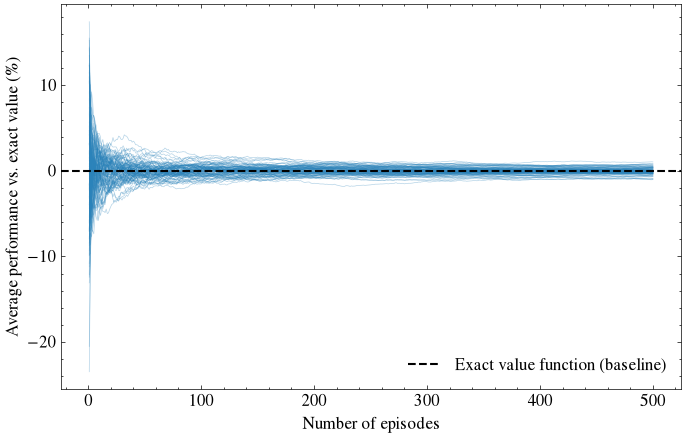

Running exact value function convergence for 2 warehouses, 50 customers, uneven capacity distribution


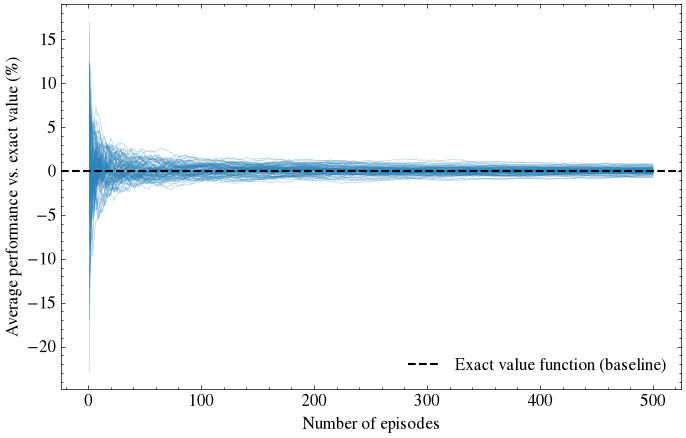

Running exact value function convergence for 3 warehouses, 50 customers, uniform capacity distribution


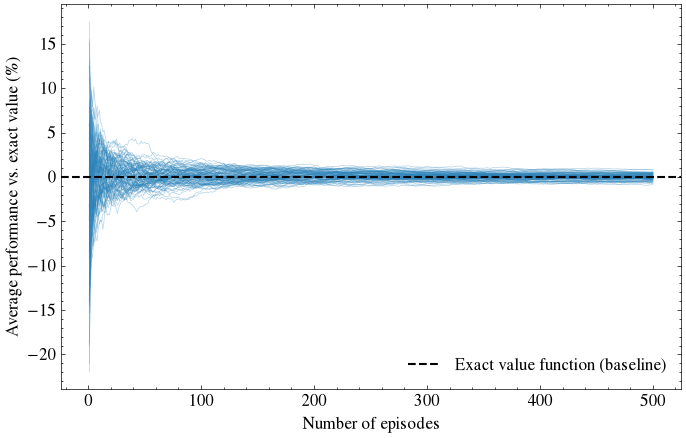

Running exact value function convergence for 3 warehouses, 50 customers, uneven capacity distribution


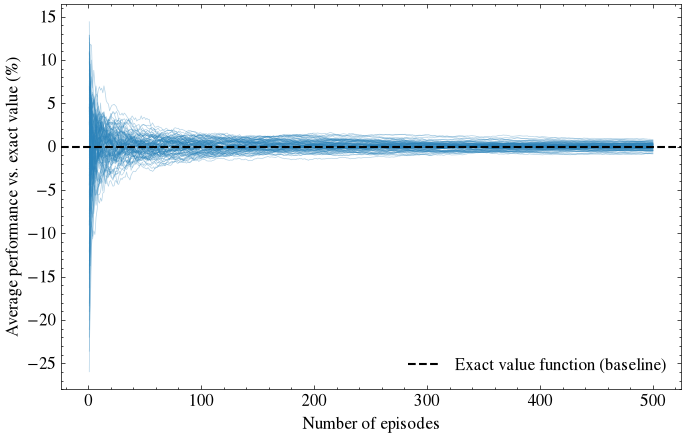

Running exact value function convergence for 4 warehouses, 50 customers, uniform capacity distribution


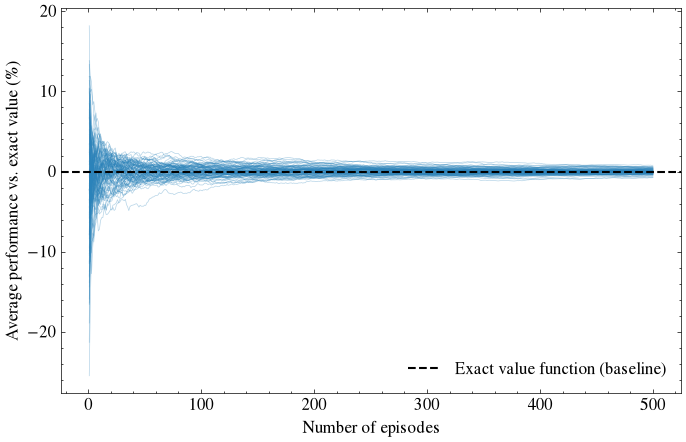

Running exact value function convergence for 4 warehouses, 50 customers, uneven capacity distribution


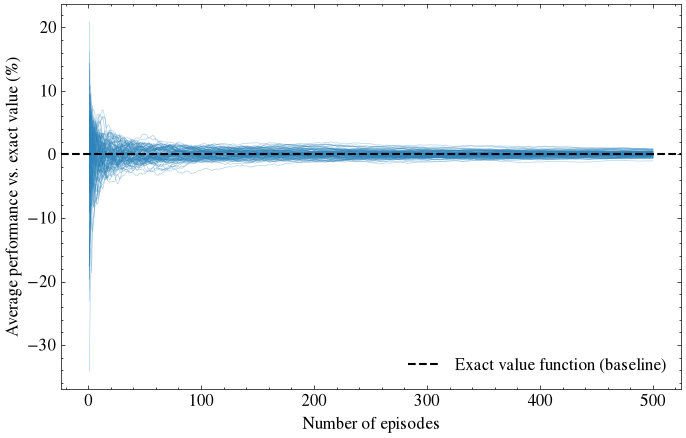

Running exact value function convergence for 5 warehouses, 50 customers, uniform capacity distribution


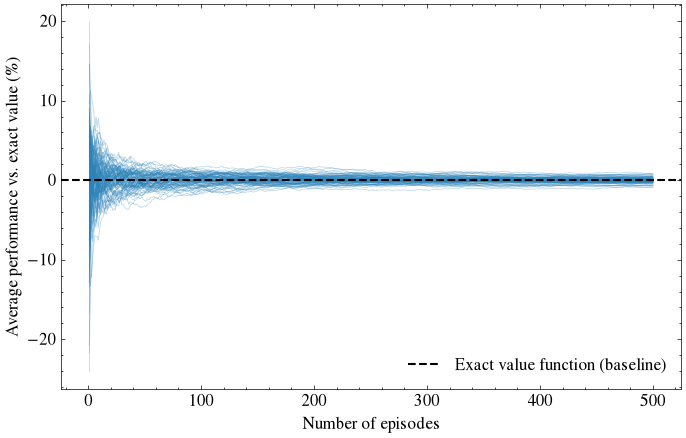

Running exact value function convergence for 5 warehouses, 50 customers, uneven capacity distribution


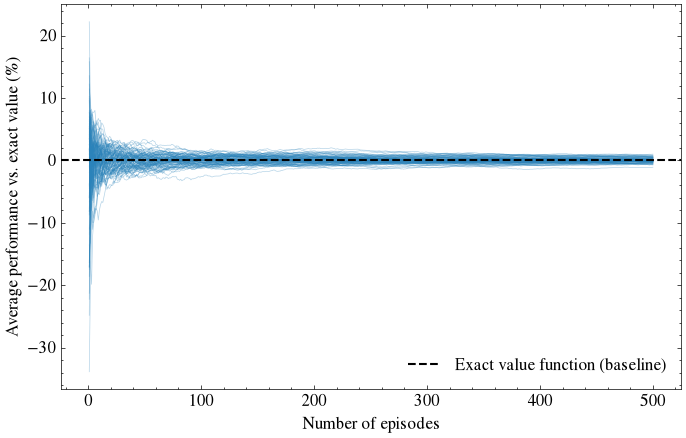

In [4]:

def plot_exact_value_function_convergence(num_warehouses, num_customers, capacity_distribution, baseline, running_averages, out_dir, as_percentage=False):
    # as_percentage=True rescales the y-axis to % deviation from the baseline (100 * (value -
    # baseline) / |baseline|, same convention as the PLA theta-sensitivity plot above) instead
    # of raw reward - baseline itself then collapses to the 0% line, and every replication curve
    # reads directly as "how far off the true expectation, in percent" regardless of instance size.
    num_episodes = running_averages.shape[1]
    episodes = np.arange(1, num_episodes + 1)
    line_color = get_colors(1)[0]

    if as_percentage:
        plot_curves = 100 * (running_averages - baseline) / abs(baseline)
        plot_baseline = 0.0
        ylabel = 'Average performance vs. exact value (%)'
    else:
        plot_curves = running_averages
        plot_baseline = baseline
        ylabel = 'Average performance'

    plt.figure(figsize=(8, 5))
    for rep_curve in plot_curves:
        plt.plot(episodes, rep_curve, color=line_color, alpha=0.35, linewidth=0.5)
    plt.axhline(plot_baseline, color='black', linestyle='--', linewidth=1.5, label='Exact value function (baseline)')

    #plt.title(f'{num_warehouses} facilities - {capacity_distribution} capacity distribution', fontweight='bold', fontsize=TITLE_FONT_SIZE)
    plt.xlabel('Number of episodes', fontsize=FONT_SIZE_LABEL)
    plt.ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    plt.xticks(fontsize=FONT_SIZE_TICK)
    plt.yticks(fontsize=FONT_SIZE_TICK)
    plt.legend(fontsize=FONT_SIZE_LEGEND, loc='lower right')
    plt.grid(False)

    os.makedirs(out_dir, exist_ok=True)
    suffix = '_pct' if as_percentage else ''
    plt.savefig(f'{out_dir}/exact_value_function_convergence_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}{suffix}.pdf', dpi=600, bbox_inches='tight')
    plt.show()


EVF_NUM_CUSTOMERS = 50
EVF_OUT_DIR = 'training/exact_value_function_training/plots'
EVF_AS_PERCENTAGE = True  # toggle: True -> y-axis is % deviation from the exact baseline, False -> raw reward

for num_warehouses in [2, 3, 4, 5]:
    for capacity_distribution in ['uniform', 'uneven']:
        print(f'Running exact value function convergence for {num_warehouses} warehouses, {EVF_NUM_CUSTOMERS} customers, {capacity_distribution} capacity distribution')
        baseline, running_averages = exact_value_function_convergence(num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution)
        plot_exact_value_function_convergence(num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution, baseline, running_averages, EVF_OUT_DIR, as_percentage=EVF_AS_PERCENTAGE)


,facilities,distribution,baseline,episode_std,CV (%),95% CI half-width @ N=10 (%),95% CI half-width @ N=20 (%),95% CI half-width @ N=50 (%),95% CI half-width @ N=100 (%),95% CI half-width @ N=200 (%),95% CI half-width @ N=300 (%)
0,2,uniform,-3271.88,235.86,7.21,4.47,3.16,2.00,1.41,1.00,0.82
1,2,uneven,-3492.05,247.98,7.10,4.40,3.11,1.97,1.39,0.98,0.80
2,3,uniform,-2635.51,206.88,7.85,4.87,3.44,2.18,1.54,1.09,0.89
3,3,uneven,-2869.43,240.56,8.38,5.20,3.67,2.32,1.64,1.16,0.95
4,4,uniform,-2206.67,161.59,7.32,4.54,3.21,2.03,1.44,1.01,0.83
5,4,uneven,-2515.38,220.17,8.75,5.43,3.84,2.43,1.72,1.21,0.99
6,5,uniform,-2098.33,162.64,7.75,4.80,3.40,2.15,1.52,1.07,0.88
7,5,uneven,-2208.84,186.78,8.46,5.24,3.71,2.34,1.66,1.17,0.96


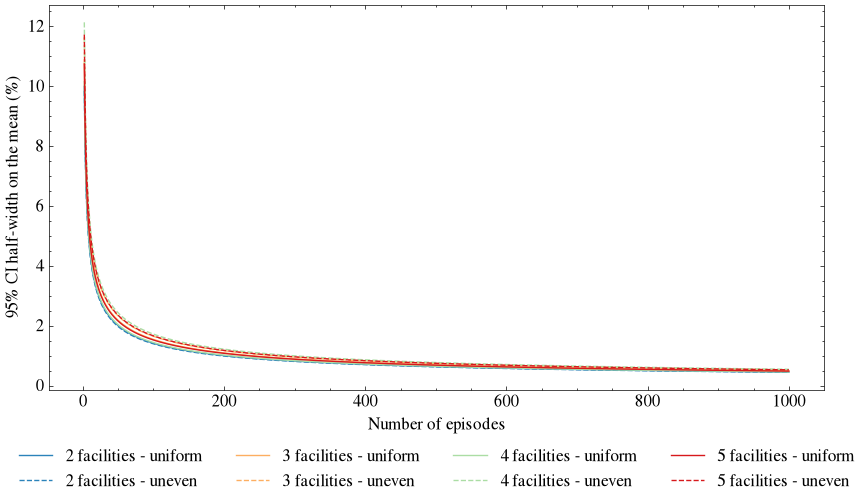

In [6]:
# Quantitative diagnosis of "how many episodes N is enough": for each (facilities, capacity
# distribution) instance with 50 customers, estimate the per-episode reward's coefficient of
# variation relative to the exact baseline V(state_0) from a large i.i.d. sample, then use the
# standard Monte Carlo scaling of the sample mean's 95% CI half-width - 1.96 * CV / sqrt(N) -
# to compare, analytically, how tight the running-average estimate gets at different N. This
# is what actually justifies a choice of N, rather than reading it off the spaghetti plots above
# by eye - the CV values below were cross-checked against the empirical spread of the
# replication curves in the plots above and the two agree closely.
from IPython.display import display
import numpy as np
import pandas as pd

EVF_ANALYSIS_NUM_SAMPLE_EPISODES = 10000
EVF_ANALYSIS_SEED = 123
EVF_ANALYSIS_N_CHOICES = [10, 20, 50, 100, 200, 300]

analysis_rows = []
for num_warehouses in [2, 3, 4, 5]:
    for capacity_distribution in ['uniform', 'uneven']:
        env = InventoryEnv(num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution, grid_size=200)
        env.set_instance(None)
        policy = ExactValueFunctionPolicy(env, num_warehouses, EVF_NUM_CUSTOMERS, capacity_distribution)
        baseline = policy.values[aggregate_state(tuple(env.warehouses_initial_capacity), policy.aggregation)]

        env.set_seed(EVF_ANALYSIS_SEED)
        sample_rewards = np.array([run_exact_value_function_episode(env, policy) for _ in range(EVF_ANALYSIS_NUM_SAMPLE_EPISODES)])

        episode_std = sample_rewards.std(ddof=1)
        cv_pct = 100 * episode_std / abs(baseline)  # coefficient of variation of a single episode's reward, relative to |baseline|

        row = {
            'facilities': num_warehouses,
            'distribution': capacity_distribution,
            'baseline': baseline,
            'episode_std': episode_std,
            'CV (%)': cv_pct,
        }
        for n in EVF_ANALYSIS_N_CHOICES:
            row[f'95% CI half-width @ N={n} (%)'] = 1.96 * cv_pct / np.sqrt(n)
        analysis_rows.append(row)

evf_analysis_df = pd.DataFrame(analysis_rows)
display(evf_analysis_df.round(2))

# Same information as a curve: 95% CI half-width vs N, per instance, so the 1/sqrt(N) decay and
# the relative ordering across instances (uneven distributions are consistently noisier than
# uniform ones) are visible at a glance, with the candidate N choices marked.
warehouse_colors = dict(zip([2, 3, 4, 5], get_colors(4)))
distribution_linestyles = {'uniform': '-', 'uneven': '--'}

plt.figure(figsize=(10, 5))
n_grid = np.arange(2, 1001)
for row in analysis_rows:
    half_width_curve = 1.96 * row['CV (%)'] / np.sqrt(n_grid)
    plt.plot(
        n_grid, half_width_curve,
        label=f"{row['facilities']} facilities - {row['distribution']}",
        color=warehouse_colors[row['facilities']],
        linestyle=distribution_linestyles[row['distribution']],
    )

#for n in EVF_ANALYSIS_N_CHOICES:
#    plt.axvline(n, color='gray', linewidth=0.8, linestyle=':')

plt.xlabel('Number of episodes', fontsize=FONT_SIZE_LABEL)
plt.ylabel('95% CI half-width on the mean (%)', fontsize=FONT_SIZE_LABEL)
plt.xticks(fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
plt.legend(fontsize=FONT_SIZE_LEGEND, loc='lower center', bbox_to_anchor=(0.5, -0.30), ncol=4)
plt.grid(False)

os.makedirs(EVF_OUT_DIR, exist_ok=True)
plt.savefig(f'{EVF_OUT_DIR}/exact_value_function_required_N_analysis.pdf', dpi=600, bbox_inches='tight')
plt.show()
